# Softmax Modular Addition AGOP Analysis

Comprehensive analysis of 19 completed Softmax experiments comparing:
- **Architectures**: MLP vs Transformer
- **Optimizers**: AdamW, Muon, SGD
- **Weight Decays**: 0.01, 0.1, 0.5, 1.0

This notebook analyzes:
1. Performance metrics (accuracy, grokking outcomes)
2. AGOP metric evolution and relationship to grokking
3. Statistical comparisons between conditions
4. Special focus on Muon breakthrough with one-hot transformers

In [5]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

sys.path.append(str(Path.cwd()))
from analysis_utils import (
    load_all_experiments, generate_summary_table, classify_grokking,
    compute_time_to_grok, statistical_comparison, filter_experiments,
    plot_agop_comparison, create_comparison_heatmap, smooth_series,
    detect_phase_transitions, compute_correlation
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Paths
RESULTS_DIR = Path('../results/softmax')
FIGURES_DIR = Path('./figures/softmax')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {RESULTS_DIR.absolute()}")
print(f"Figures will be saved to: {FIGURES_DIR.absolute()}")

Results directory: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/../results/softmax
Figures will be saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/figures/softmax


## Load All Softmax Experiments

In [6]:
experiments = load_all_experiments(RESULTS_DIR)
print(f"Loaded {len(experiments)} experiments")

summary_df = generate_summary_table(experiments)
print(f"\nSummary of experiments:")
display(summary_df.sort_values(['architecture', 'optimizer', 'weight_decay']))

Loaded 24 experiments

Summary of experiments:


,experiment,architecture,optimizer,weight_decay,lr,final_test_acc,max_test_acc,final_train_acc,grokked,grok_epoch
0,softmax_mlp_adamw_wd0.01_seed42,mlp,adamw,0.01,0.001,0.275027,0.275027,1.000000,False,-1
1,softmax_mlp_adamw_wd0.1_seed42,mlp,adamw,0.10,0.001,0.934963,0.934963,1.000000,False,-1
2,softmax_mlp_adamw_wd0.5_seed42,mlp,adamw,0.50,0.001,0.998087,0.998087,1.000000,True,13000
3,softmax_mlp_adamw_wd1.0_seed42,mlp,adamw,1.00,0.001,0.997237,0.999575,1.000000,True,7800
4,softmax_mlp_muon_wd0.01_seed42,mlp,muon,0.01,0.001,0.325399,0.325399,1.000000,False,-1
5,softmax_mlp_muon_wd0.1_seed42,mlp,muon,0.10,0.001,0.473114,0.473114,1.000000,False,-1
6,softmax_mlp_muon_wd0.5_seed42,mlp,muon,0.50,0.001,0.703294,0.703294,0.952594,False,-1
7,softmax_mlp_muon_wd1.0_seed42,mlp,muon,1.00,0.001,0.567269,0.569182,0.871811,False,-1
8,softmax_mlp_sgd_wd0.01_seed42,mlp,sgd,0.01,0.001,0.007651,0.009777,0.012968,False,-1
9,softmax_mlp_sgd_wd0.1_seed42,mlp,sgd,0.10,0.001,0.007651,0.010414,0.012968,False,-1


## Quick Statistics

In [27]:
# Overall statistics
total = len(summary_df)
grokked = summary_df['grokked'].sum()
grok_rate = grokked / total * 100

print(f"="*80)
print(f"SOFTMAX DATASET - OVERALL STATISTICS")
print(f"="*80)
print(f"Total experiments: {total}")
print(f"Grokked: {grokked} ({grok_rate:.1f}%)")
print(f"Failed to grok: {total - grokked} ({100-grok_rate:.1f}%)")
print()

# By architecture
print(f"By Architecture:")
print(f"-"*80)
for arch in summary_df['architecture'].unique():
    arch_df = summary_df[summary_df['architecture'] == arch]
    arch_grok = arch_df['grokked'].sum()
    arch_total = len(arch_df)
    print(f"  {arch.upper()}: {arch_grok}/{arch_total} grokked ({arch_grok/arch_total*100:.1f}%)")
print()

# By optimizer
print(f"By Optimizer:")
print(f"-"*80)
for opt in summary_df['optimizer'].unique():
    opt_df = summary_df[summary_df['optimizer'] == opt]
    opt_grok = opt_df['grokked'].sum()
    opt_total = len(opt_df)
    print(f"  {opt.upper()}: {opt_grok}/{opt_total} grokked ({opt_grok/opt_total*100:.1f}%)")

print(f"="*80)

# Store grok rate for later use
grok_rate_value = grok_rate

SOFTMAX DATASET - OVERALL STATISTICS
Total experiments: 24
Grokked: 9 (37.5%)
Failed to grok: 15 (62.5%)

By Architecture:
--------------------------------------------------------------------------------
  MLP: 2/12 grokked (16.7%)
  TRANSFORMER: 7/12 grokked (58.3%)

By Optimizer:
--------------------------------------------------------------------------------
  ADAMW: 6/8 grokked (75.0%)
  MUON: 3/8 grokked (37.5%)
  SGD: 0/8 grokked (0.0%)


---
# Section 0: Training Dynamics - Accuracy and Loss Curves

**First Analytical Insight**: Visualize training and test accuracy/loss over epochs for all completed experiments. 
Red dashed vertical lines indicate the "grokking epoch" where test performance catches up with train performance.

In [28]:
def detect_grokking_epoch(train_acc, test_acc, grok_threshold=0.85, min_epoch=100):
    """
    Detect the epoch where grokking occurs (test accuracy exceeds threshold).
    
    Args:
        train_acc: Array of training accuracies (unused, kept for compatibility)
        test_acc: Array of test accuracies
        grok_threshold: Test accuracy threshold to define grokking (default 0.85)
        min_epoch: Minimum epoch to start checking (avoid early noise)
    
    Returns:
        Grokking epoch (int) or None if no grokking detected
    """
    if len(test_acc) < min_epoch:
        return None
    
    # Find the first epoch where test accuracy exceeds the grokking threshold
    for i in range(min_epoch, len(test_acc)):
        if test_acc[i] > grok_threshold:
            return i
    
    return None

print("Grokking detection function loaded.")
print(f"Grokking definition: test_acc > 0.85")

Grokking detection function loaded.
Grokking definition: test_acc > 0.85


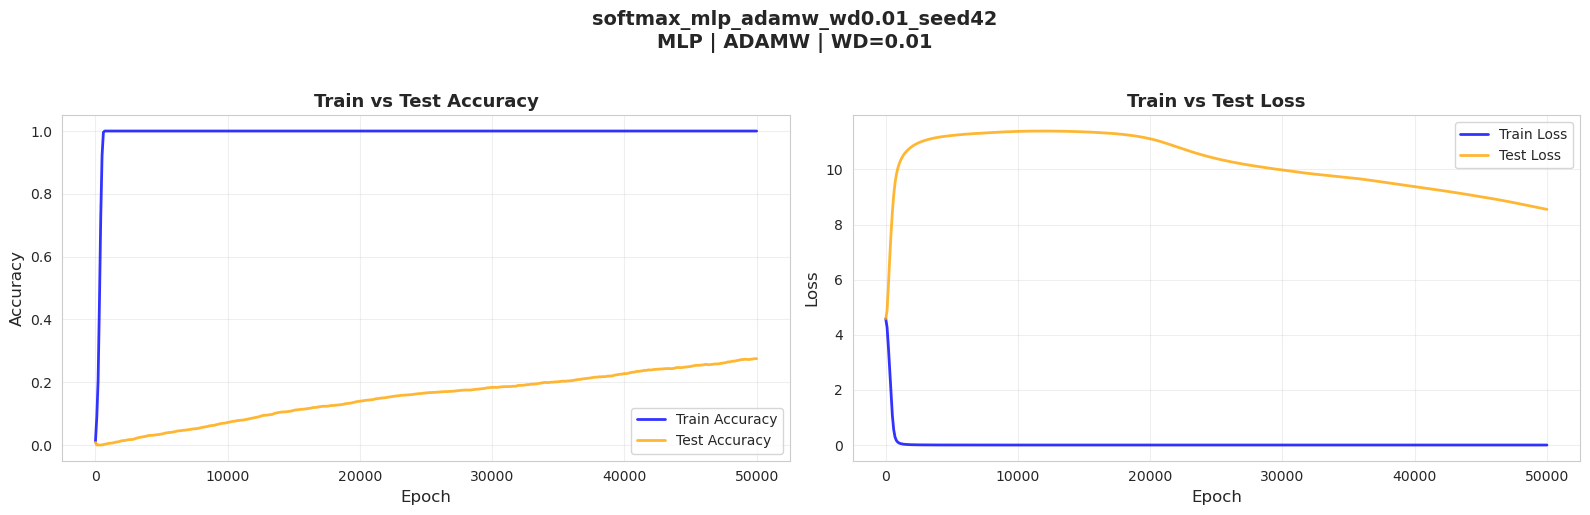

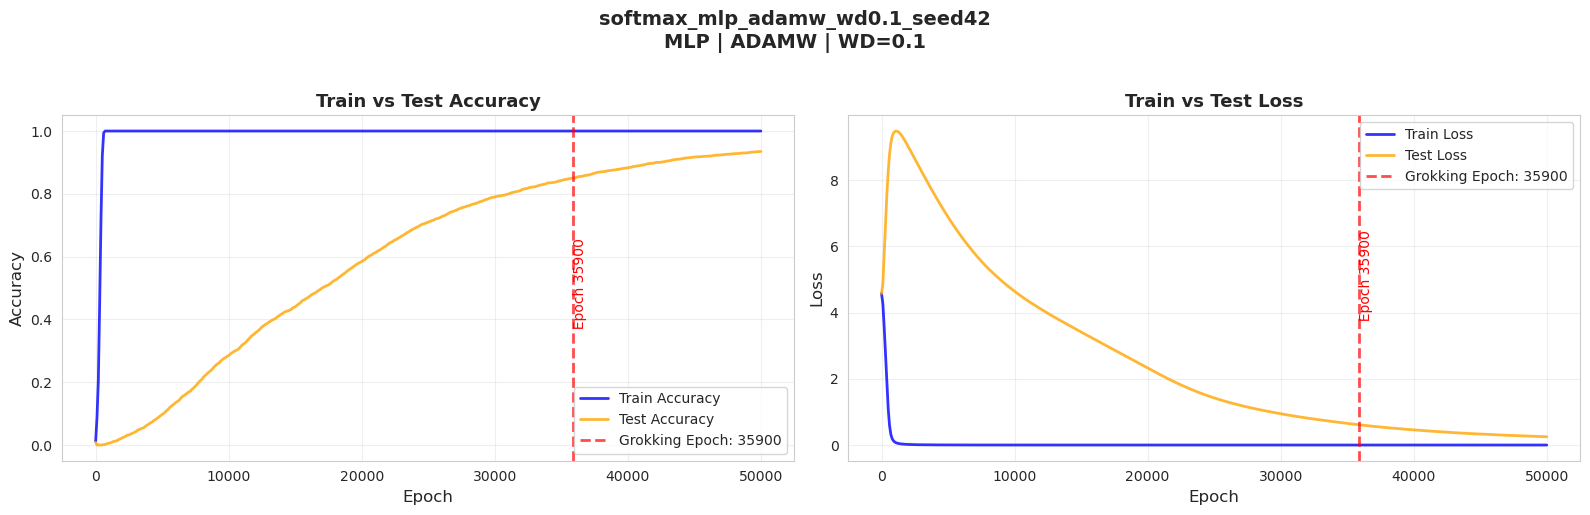

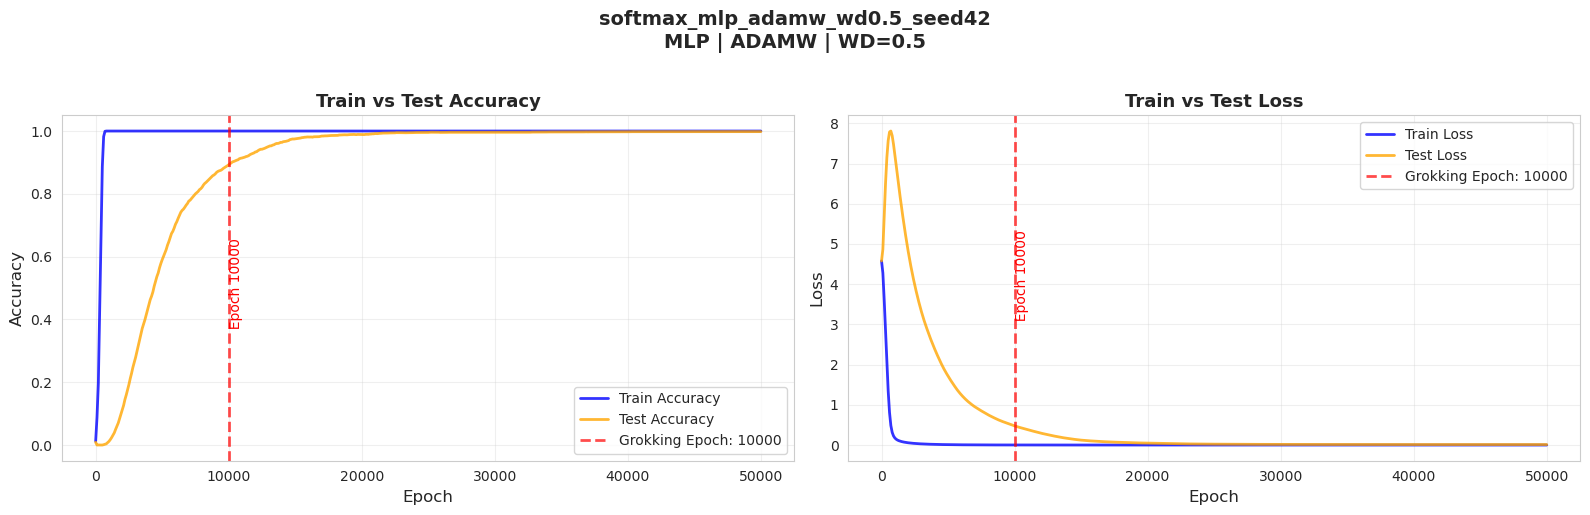

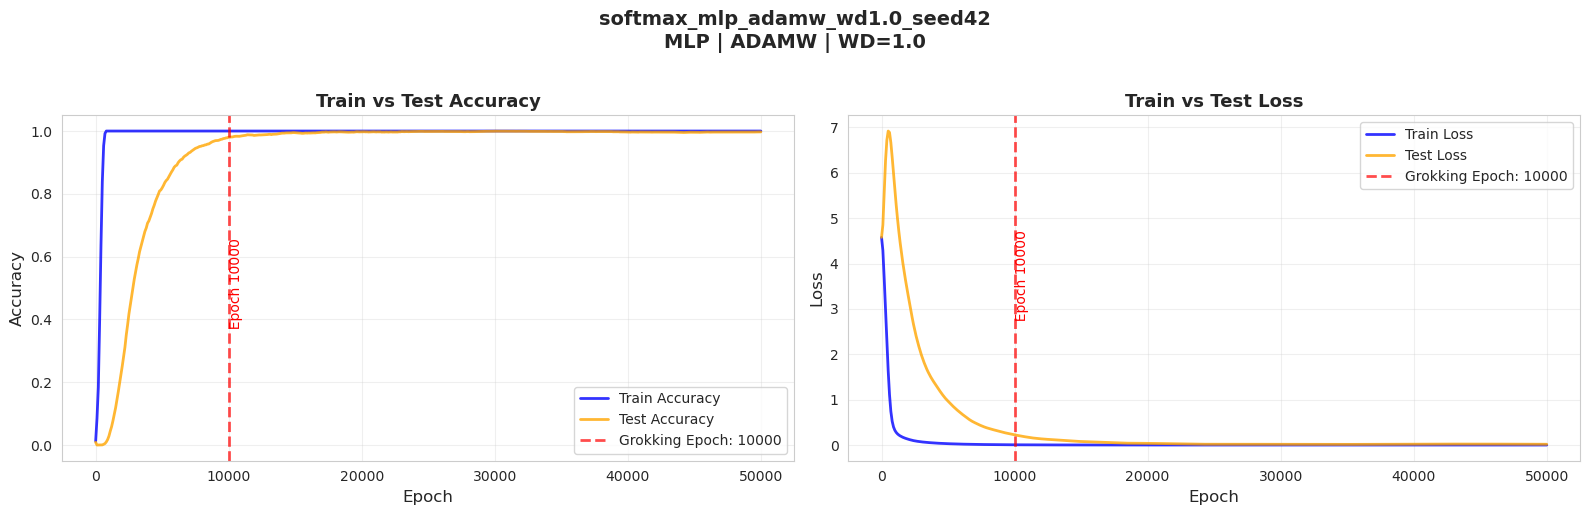

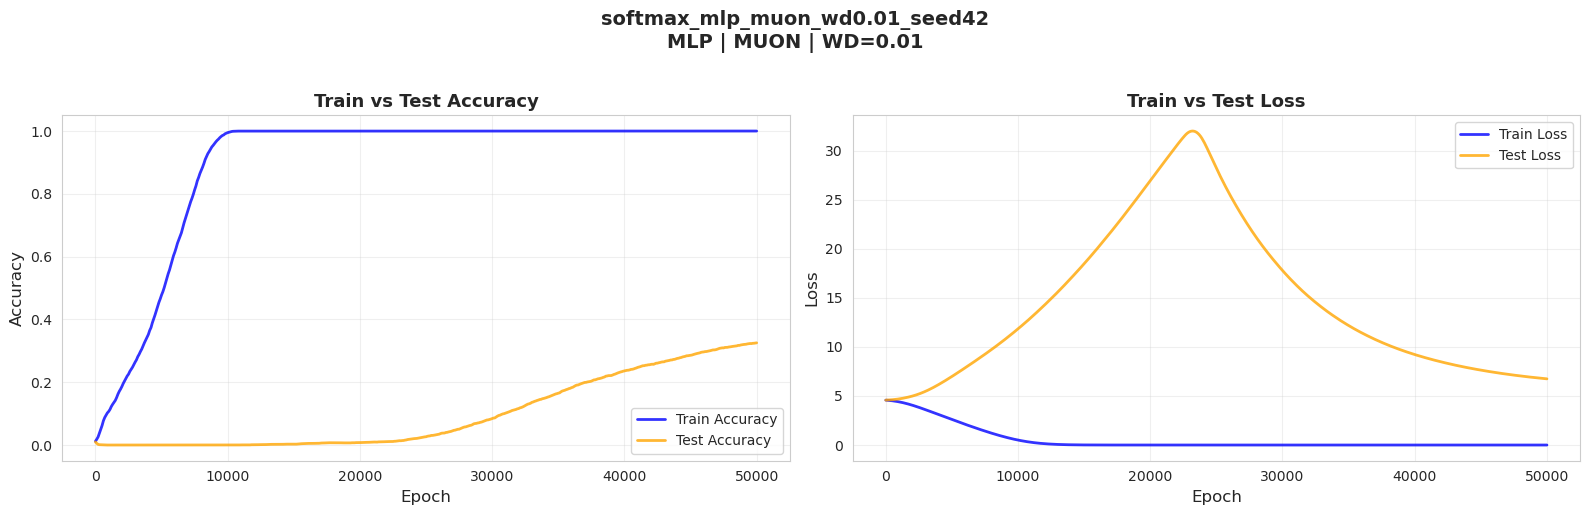

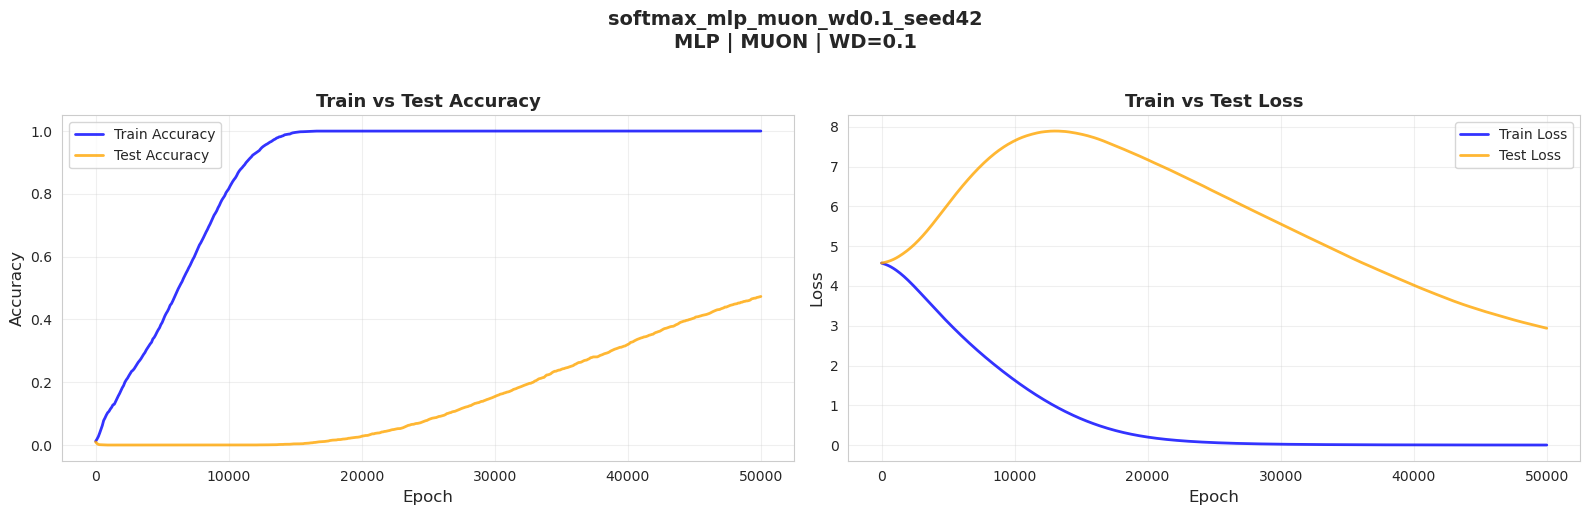

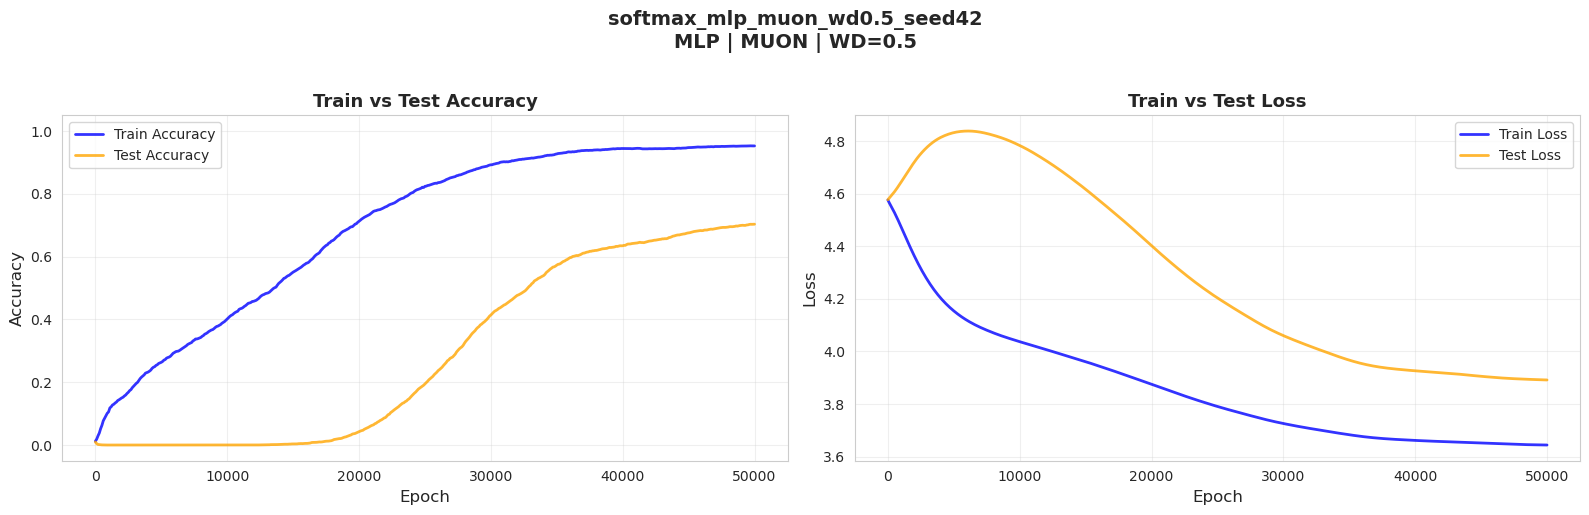

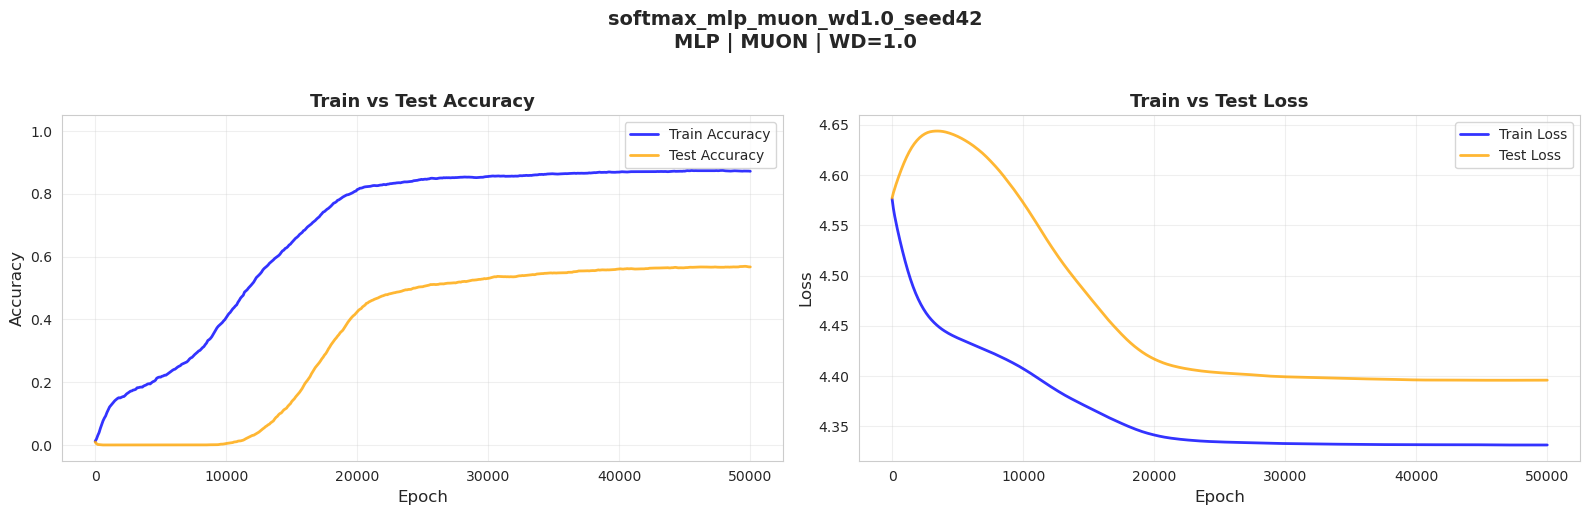

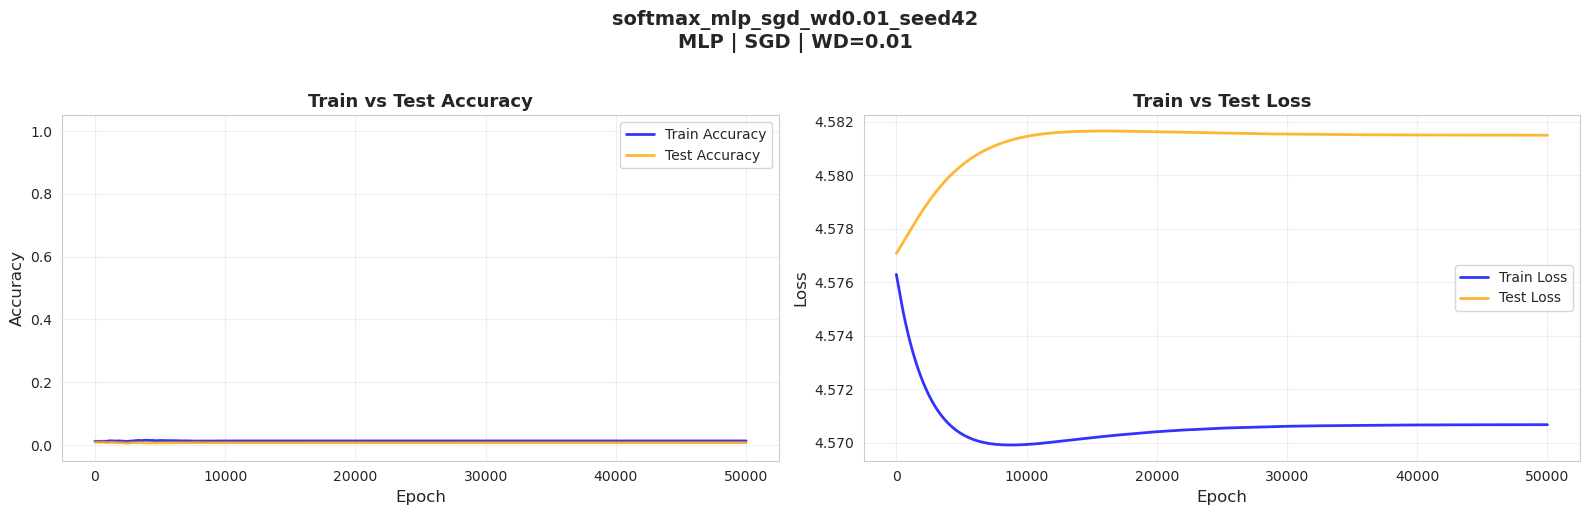

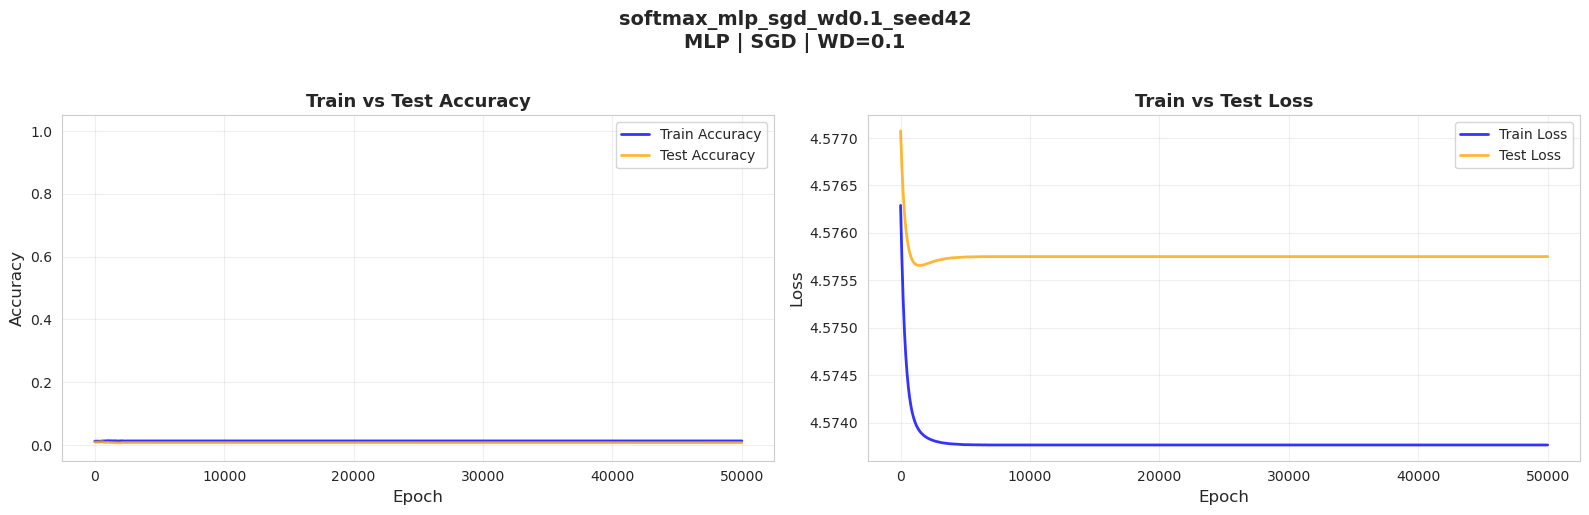

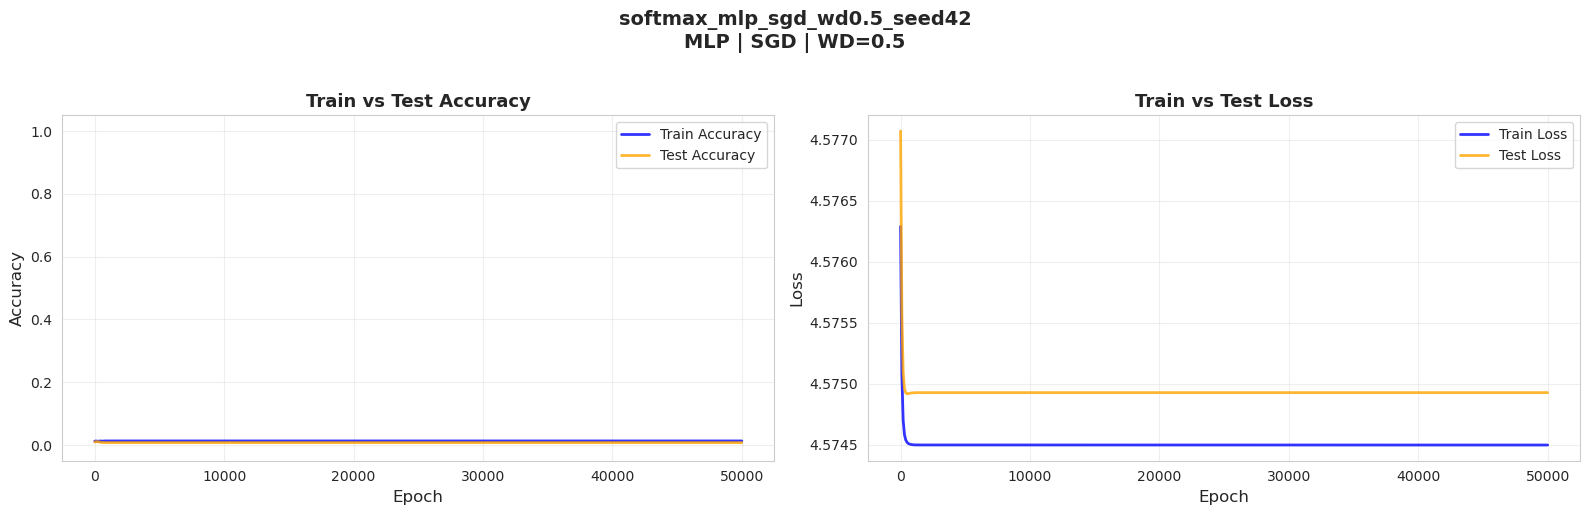

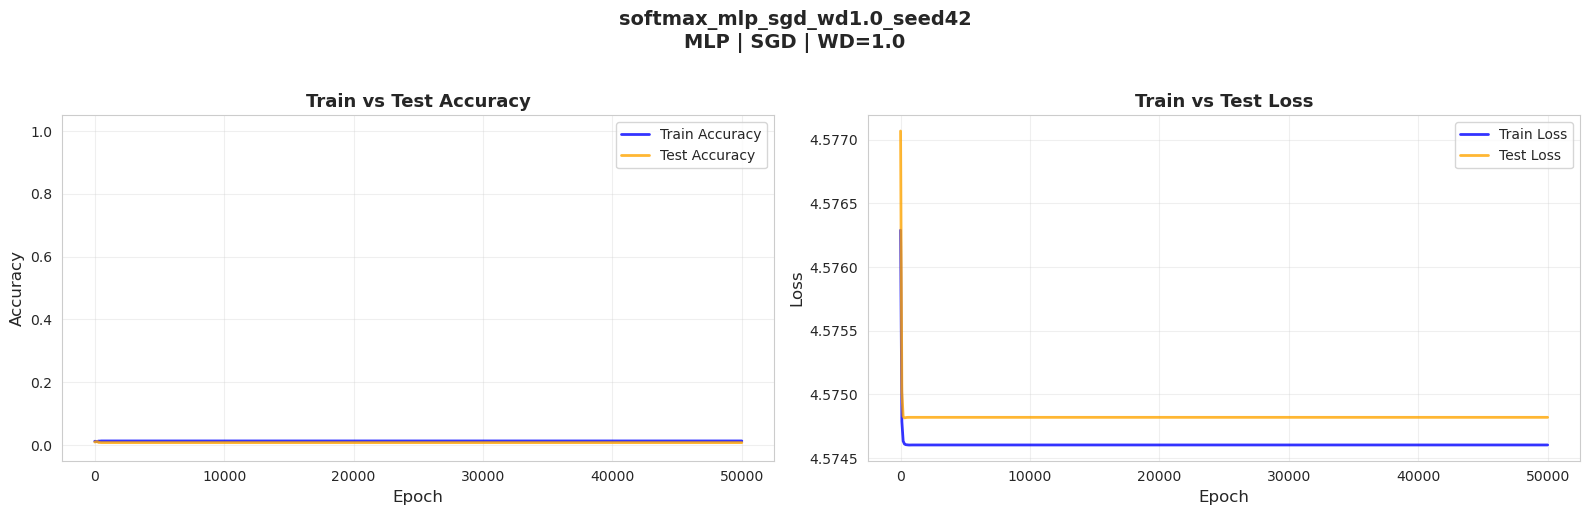

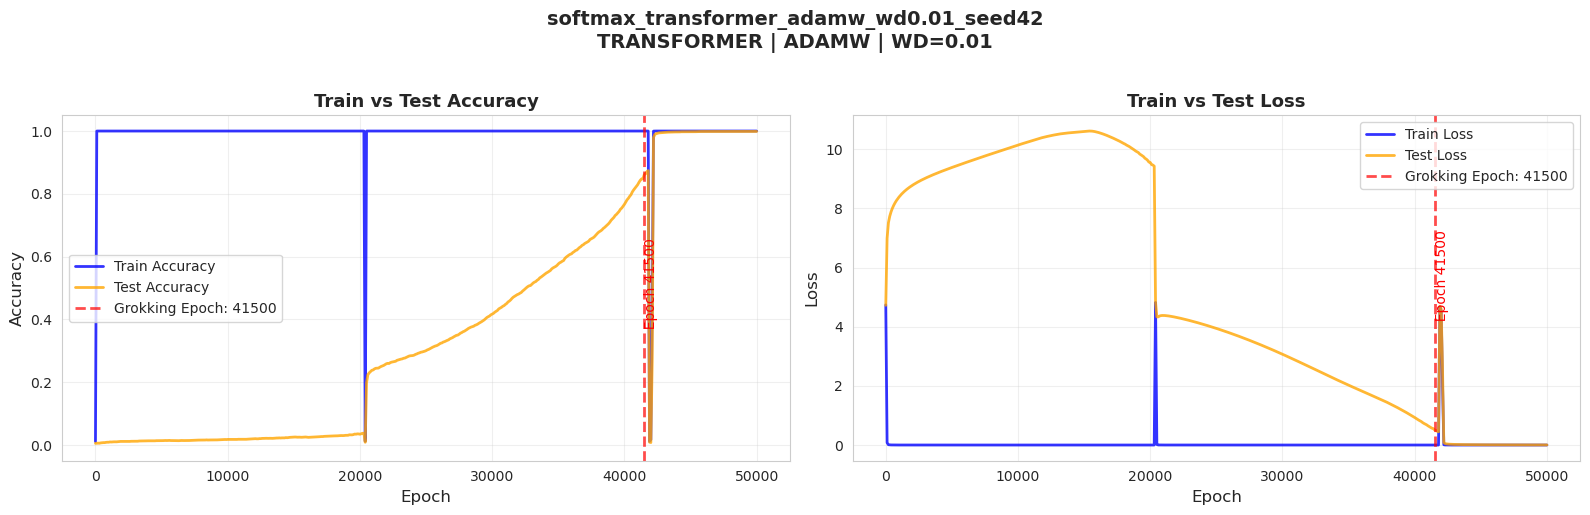

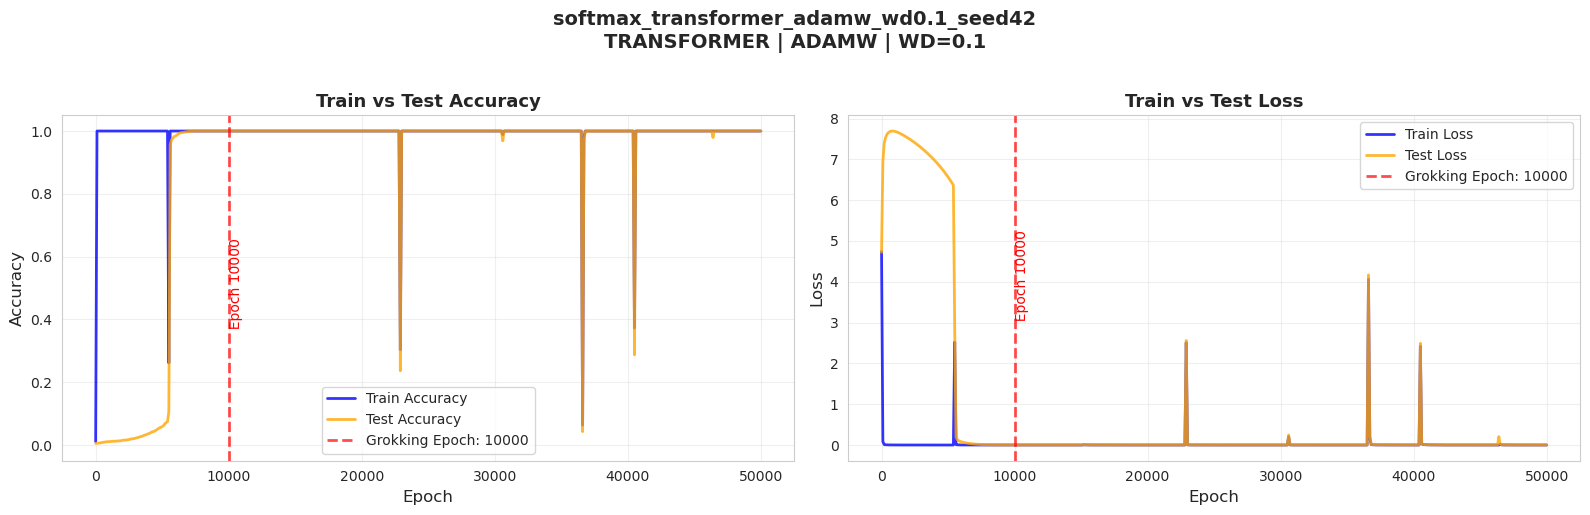

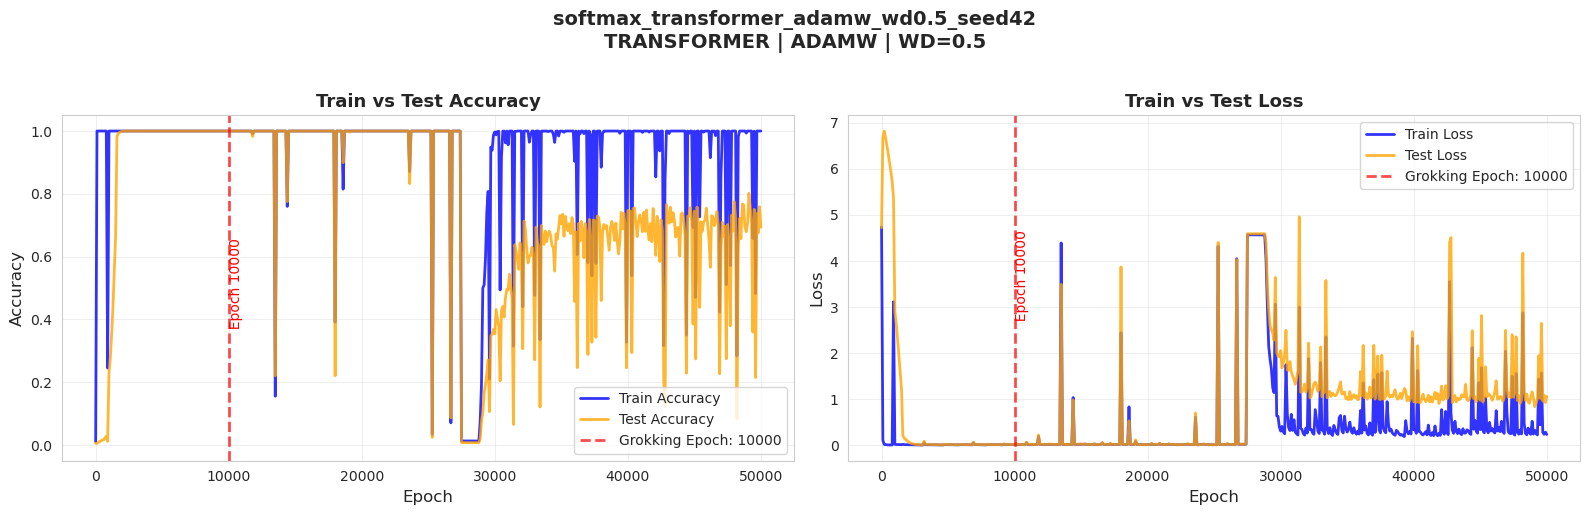

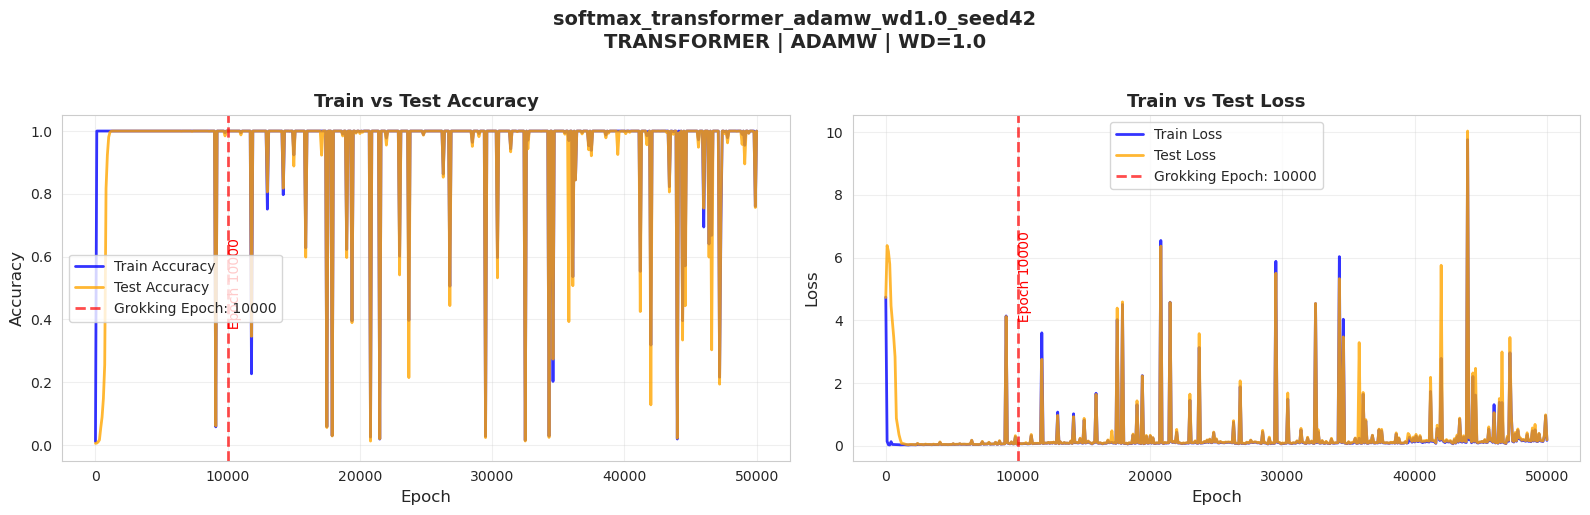

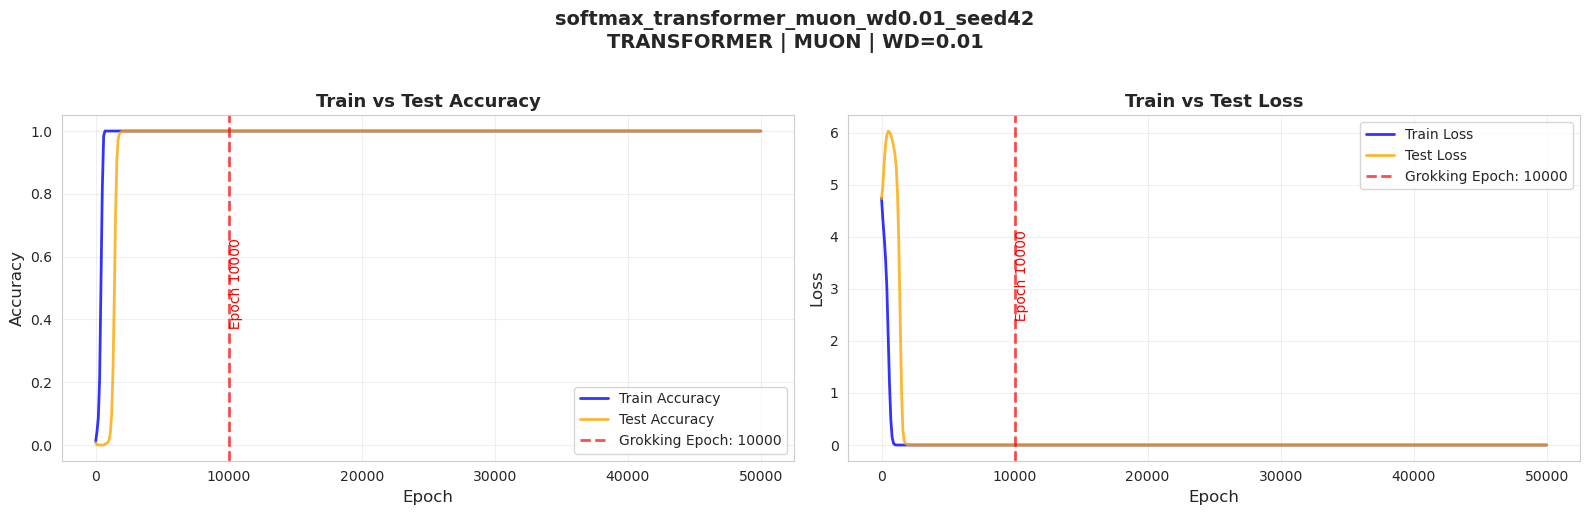

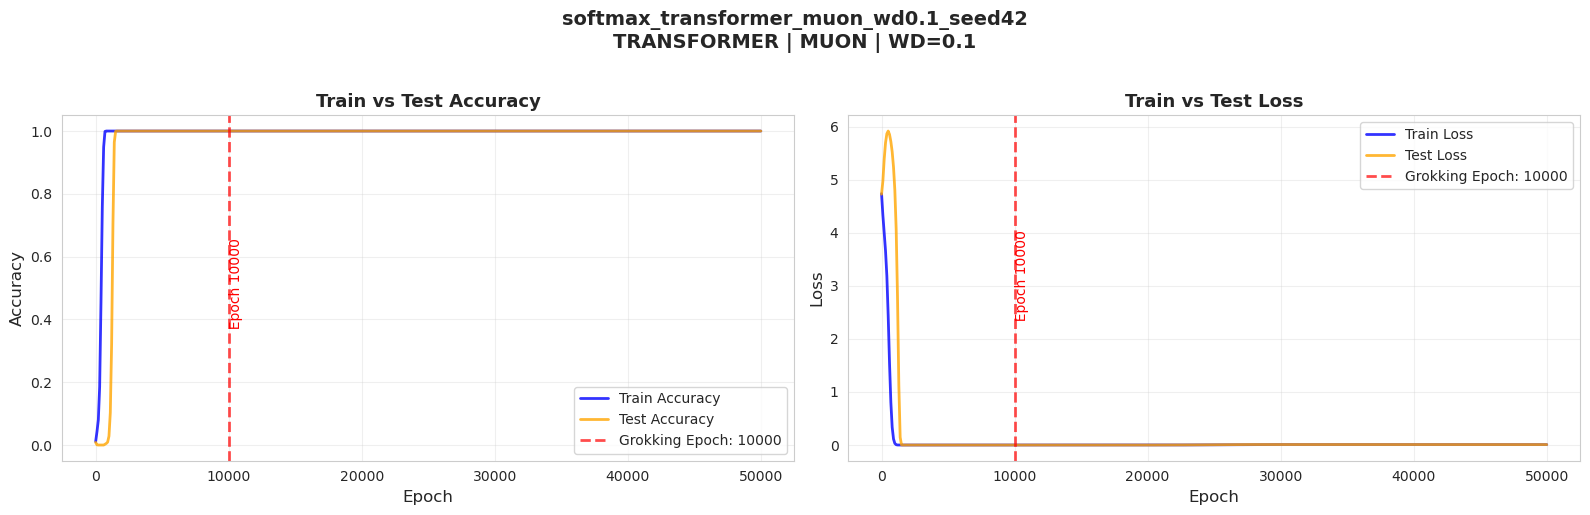

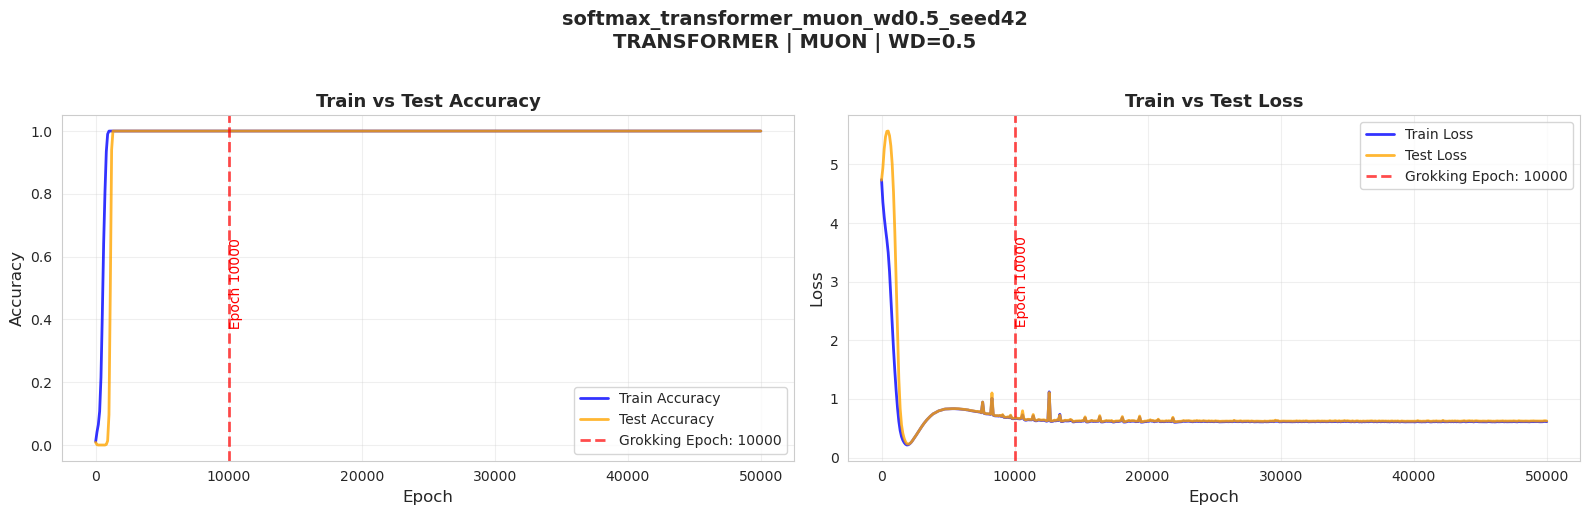

Skipping softmax_transformer_muon_wd1.0_seed42: missing required metrics
Skipping softmax_transformer_sgd_wd0.01_seed42: missing required metrics
Skipping softmax_transformer_sgd_wd0.1_seed42: missing required metrics
Skipping softmax_transformer_sgd_wd0.5_seed42: missing required metrics
Skipping softmax_transformer_sgd_wd1.0_seed42: missing required metrics

Generated 19 training dynamics plots
Saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/figures/softmax/training_dynamics


In [29]:
## Generate Training Dynamics Plots for All Experiments

# Create a subdirectory for training dynamics plots
TRAIN_DYNAMICS_DIR = FIGURES_DIR / 'training_dynamics'
TRAIN_DYNAMICS_DIR.mkdir(parents=True, exist_ok=True)

grokking_summary = []

for exp_name, exp_data in experiments.items():
    history = exp_data.get('history', {})
    config = exp_data.get('config', {})
    
    # Check if we have the required data
    required_keys = ['train_acc', 'test_acc', 'train_loss', 'test_loss']
    if not all(key in history for key in required_keys):
        print(f"Skipping {exp_name}: missing required metrics")
        continue
    
    # Extract data
    epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
    train_acc = np.array(history['train_acc'])
    test_acc = np.array(history['test_acc'])
    train_loss = np.array(history['train_loss'])
    test_loss = np.array(history['test_loss'])
    
    # Detect grokking epoch
    grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
    grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
    
    # Store summary
    grokking_summary.append({
        'experiment': exp_name,
        'architecture': config.get('architecture', 'unknown'),
        'optimizer': config.get('optimizer', 'unknown'),
        'weight_decay': config.get('weight_decay', 0),
        'grok_epoch': grok_epoch if grok_epoch else -1,
        'final_test_acc': test_acc[-1],
        'final_train_acc': train_acc[-1]
    })
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Accuracy
    ax1.plot(epochs, train_acc, 'b-', linewidth=2, label='Train Accuracy', alpha=0.8)
    ax1.plot(epochs, test_acc, 'orange', linewidth=2, label='Test Accuracy', alpha=0.8)
    
    if grok_epoch is not None:
        ax1.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, 
                   label=f'Grokking Epoch: {grok_epoch}', alpha=0.7)
        ax1.text(grok_epoch, 0.5, f'  Epoch {grok_epoch}', 
                rotation=90, verticalalignment='center', fontsize=10, color='red')
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Train vs Test Accuracy', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(alpha=0.3)
    ax1.set_ylim([-0.05, 1.05])
    
    # Plot 2: Loss
    ax2.plot(epochs, train_loss, 'b-', linewidth=2, label='Train Loss', alpha=0.8)
    ax2.plot(epochs, test_loss, 'orange', linewidth=2, label='Test Loss', alpha=0.8)
    
    if grok_epoch is not None:
        ax2.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, 
                   label=f'Grokking Epoch: {grok_epoch}', alpha=0.7)
        ax2.text(grok_epoch, ax2.get_ylim()[1] * 0.5, f'  Epoch {grok_epoch}', 
                rotation=90, verticalalignment='center', fontsize=10, color='red')
    
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Train vs Test Loss', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(alpha=0.3)
    
    # Overall title
    arch = config.get('architecture', 'unknown')
    opt = config.get('optimizer', 'unknown')
    wd = config.get('weight_decay', 0)
    fig.suptitle(f'{exp_name}\n{arch.upper()} | {opt.upper()} | WD={wd}', 
                fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # Save figure
    safe_name = exp_name.replace('/', '_').replace(' ', '_')
    plt.savefig(TRAIN_DYNAMICS_DIR / f'{safe_name}_dynamics.png', dpi=300, bbox_inches='tight')
    
    # Display inline for interactive analysis
    plt.show()
    plt.close()

print(f"\n{'='*80}")
print(f"Generated {len(grokking_summary)} training dynamics plots")
print(f"Saved to: {TRAIN_DYNAMICS_DIR.absolute()}")
print(f"{'='*80}")


In [30]:
## Summary: Detected Grokking Epochs

# Create DataFrame from summary
grok_summary_df = pd.DataFrame(grokking_summary)
grok_summary_df = grok_summary_df.sort_values(['architecture', 'optimizer', 'weight_decay'])

print(f"\nGrokking Detection Summary:")
print(f"{'='*80}")
print(f"Total experiments analyzed: {len(grok_summary_df)}")
print(f"Experiments with detected grokking: {(grok_summary_df['grok_epoch'] > 0).sum()}")
print(f"{'='*80}\n")

# Show only experiments that grokked
grokked_df = grok_summary_df[grok_summary_df['grok_epoch'] > 0].copy()
if len(grokked_df) > 0:
    print(f"\nExperiments with Detected Grokking:")
    print(f"{'-'*80}")
    display(grokked_df[['experiment', 'architecture', 'optimizer', 'weight_decay', 
                        'grok_epoch', 'final_test_acc', 'final_train_acc']])
else:
    print("\nNo grokking detected in any experiment with current threshold settings.")

# Show full summary table
print(f"\n\nFull Summary (all experiments):")
print(f"{'-'*80}")
display(grok_summary_df[['experiment', 'architecture', 'optimizer', 'weight_decay', 
                         'grok_epoch', 'final_test_acc', 'final_train_acc']])



Grokking Detection Summary:
Total experiments analyzed: 19
Experiments with detected grokking: 10


Experiments with Detected Grokking:
--------------------------------------------------------------------------------


,experiment,architecture,optimizer,weight_decay,grok_epoch,final_test_acc,final_train_acc
1,softmax_mlp_adamw_wd0.1_seed42,mlp,adamw,0.10,35900,0.934963,1.0
2,softmax_mlp_adamw_wd0.5_seed42,mlp,adamw,0.50,10000,0.998087,1.0
3,softmax_mlp_adamw_wd1.0_seed42,mlp,adamw,1.00,10000,0.997237,1.0
12,softmax_transformer_adamw_wd0.01_seed42,transformer,adamw,0.01,41500,0.998725,1.0
13,softmax_transformer_adamw_wd0.1_seed42,transformer,adamw,0.10,10000,1.000000,1.0
14,softmax_transformer_adamw_wd0.5_seed42,transformer,adamw,0.50,10000,0.693943,1.0
15,softmax_transformer_adamw_wd1.0_seed42,transformer,adamw,1.00,10000,1.000000,1.0
16,softmax_transformer_muon_wd0.01_seed42,transformer,muon,0.01,10000,1.000000,1.0
17,softmax_transformer_muon_wd0.1_seed42,transformer,muon,0.10,10000,1.000000,1.0
18,softmax_transformer_muon_wd0.5_seed42,transformer,muon,0.50,10000,1.000000,1.0




Full Summary (all experiments):
--------------------------------------------------------------------------------


,experiment,architecture,optimizer,weight_decay,grok_epoch,final_test_acc,final_train_acc
0,softmax_mlp_adamw_wd0.01_seed42,mlp,adamw,0.01,-1,0.275027,1.000000
1,softmax_mlp_adamw_wd0.1_seed42,mlp,adamw,0.10,35900,0.934963,1.000000
2,softmax_mlp_adamw_wd0.5_seed42,mlp,adamw,0.50,10000,0.998087,1.000000
3,softmax_mlp_adamw_wd1.0_seed42,mlp,adamw,1.00,10000,0.997237,1.000000
4,softmax_mlp_muon_wd0.01_seed42,mlp,muon,0.01,-1,0.325399,1.000000
5,softmax_mlp_muon_wd0.1_seed42,mlp,muon,0.10,-1,0.473114,1.000000
6,softmax_mlp_muon_wd0.5_seed42,mlp,muon,0.50,-1,0.703294,0.952594
7,softmax_mlp_muon_wd1.0_seed42,mlp,muon,1.00,-1,0.567269,0.871811
8,softmax_mlp_sgd_wd0.01_seed42,mlp,sgd,0.01,-1,0.007651,0.012968
9,softmax_mlp_sgd_wd0.1_seed42,mlp,sgd,0.10,-1,0.007651,0.012968


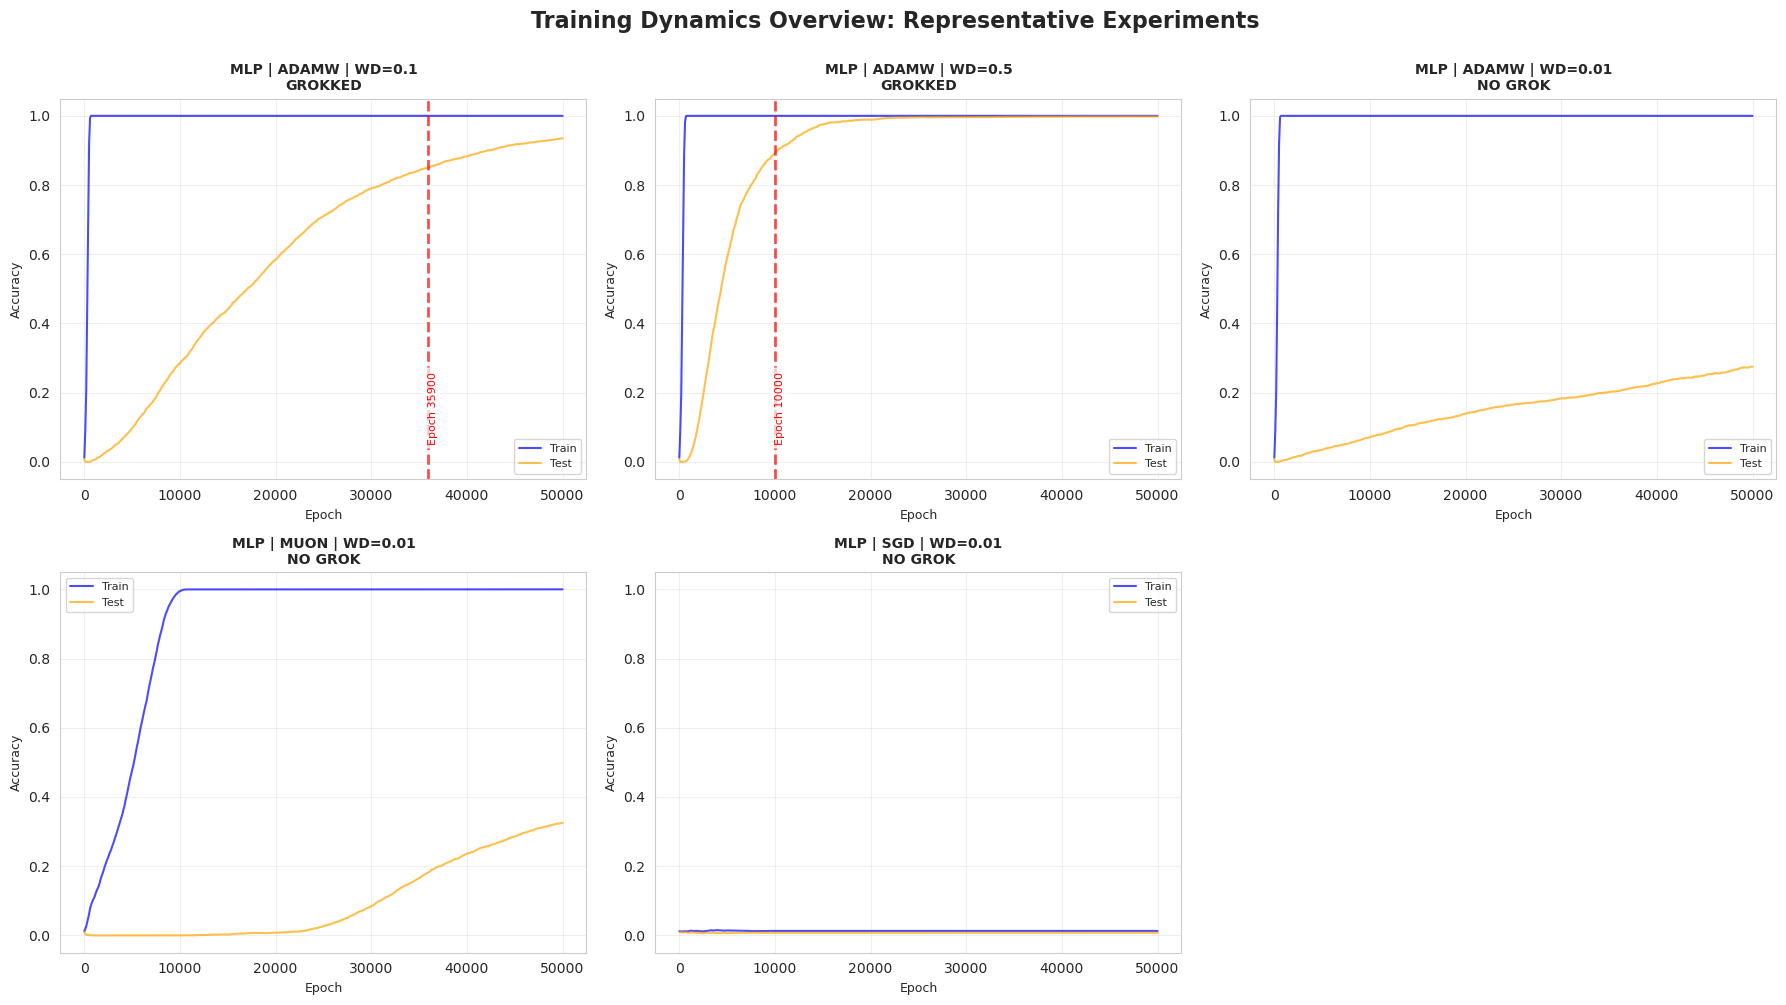

Saved overview figure: training_dynamics_overview.png


In [31]:
## Create Combined Overview Plot

# Select representative experiments: grokked and non-grokked
exp_to_plot = []

# Get grokked experiments
if len(grokked_df) > 0:
    for _, row in grokked_df.head(2).iterrows():
        exp_to_plot.append(row['experiment'])

# Get some non-grokked experiments from different configurations
non_grok_df = grok_summary_df[grok_summary_df['grok_epoch'] <= 0]
if len(non_grok_df) > 0:
    # Try to get diverse non-grokked examples
    for arch in ['mlp', 'transformer']:
        for opt in ['adamw', 'muon', 'sgd']:
            subset = non_grok_df[(non_grok_df['architecture'] == arch) & 
                                 (non_grok_df['optimizer'] == opt)]
            if len(subset) > 0:
                exp_to_plot.append(subset.iloc[0]['experiment'])
                if len(exp_to_plot) >= 6:
                    break
        if len(exp_to_plot) >= 6:
            break

# Limit to 6 plots for readability
exp_to_plot = exp_to_plot[:6]

if len(exp_to_plot) > 0:
    n_plots = len(exp_to_plot)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, exp_name in enumerate(exp_to_plot):
        ax = axes[idx]
        exp_data = experiments[exp_name]
        history = exp_data['history']
        config = exp_data['config']
        
        epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
        train_acc = np.array(history['train_acc'])
        test_acc = np.array(history['test_acc'])
        
        # Detect grokking
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        
        # Plot
        ax.plot(epochs, train_acc, 'b-', linewidth=1.5, label='Train', alpha=0.7)
        ax.plot(epochs, test_acc, 'orange', linewidth=1.5, label='Test', alpha=0.7)
        
        if grok_epoch is not None:
            ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)
            ax.text(grok_epoch, 0.05, f'Epoch {grok_epoch}', 
                   rotation=90, verticalalignment='bottom', fontsize=8, color='red',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        
        # Title
        arch = config.get('architecture', 'unknown')
        opt = config.get('optimizer', 'unknown')
        wd = config.get('weight_decay', 0)
        status = "GROKKED" if grok_epoch else "NO GROK"
        ax.set_title(f'{arch.upper()} | {opt.upper()} | WD={wd}\n{status}', 
                    fontsize=10, fontweight='bold')
        
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Accuracy', fontsize=9)
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)
        ax.set_ylim([-0.05, 1.05])
    
    # Hide unused subplots
    for idx in range(len(exp_to_plot), len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle('Training Dynamics Overview: Representative Experiments', 
                fontsize=16, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'training_dynamics_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved overview figure: training_dynamics_overview.png")
else:
    print("No experiments to plot.")


## Focused Analysis: Configurations that Achieve Grokking

Deep dive into configurations that achieve grokking with the softmax transformer.
We'll examine how different optimizers and weight decay settings affect the grokking phenomenon.


In [32]:
# Get all transformer experiments for comparison
transformer_exps = {name: data for name, data in experiments.items() 
                    if data['config'].get('architecture') == 'transformer'}

print(f"Transformer experiments: {len(transformer_exps)}")

# Get transformer experiments grouped by optimizer for later AGOP analysis
transformer_by_opt = {}
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in transformer_exps.items() 
                if data['config'].get('optimizer') == opt}
    if len(opt_exps) > 0:
        transformer_by_opt[opt] = sorted(opt_exps.items(), 
                                         key=lambda x: x[1]['config'].get('weight_decay', 0))

# Group by optimizer
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in transformer_exps.items() 
                if data['config'].get('optimizer') == opt}
    
    if len(opt_exps) == 0:
        continue
    
    print(f"\n{opt.upper()} Transformer experiments: {len(opt_exps)}")
    
    # Sort by weight decay
    sorted_exps = sorted(opt_exps.items(), 
                         key=lambda x: x[1]['config'].get('weight_decay', 0))
    
    # Count grokking
    grok_count = sum(1 for _, data in sorted_exps 
                     if classify_grokking(data))
    print(f"  Grokked: {grok_count}/{len(sorted_exps)}")
    
    for exp_name, exp_data in sorted_exps:
        wd = exp_data['config'].get('weight_decay', 0)
        history = exp_data['history']
        
        if 'test_acc' not in history:
            continue
        
        test_acc = np.array(history['test_acc'])
        train_acc = np.array(history['train_acc'])
        
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        epochs = np.array(history.get('epoch', range(len(test_acc))))
        grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        
        final_test = test_acc[-1]
        
        if grok_epoch:
            print(f"  WD={wd:5.2f}: GROKKED at epoch {grok_epoch:5d} | Final test acc: {final_test:.4f}")
        else:
            print(f"  WD={wd:5.2f}: NO GROK                  | Final test acc: {final_test:.4f}")


Transformer experiments: 12

ADAMW Transformer experiments: 4
  Grokked: 4/4
  WD= 0.01: GROKKED at epoch 41500 | Final test acc: 0.9987
  WD= 0.10: GROKKED at epoch 10000 | Final test acc: 1.0000
  WD= 0.50: GROKKED at epoch 10000 | Final test acc: 0.6939
  WD= 1.00: GROKKED at epoch 10000 | Final test acc: 1.0000

MUON Transformer experiments: 4
  Grokked: 3/4
  WD= 0.01: GROKKED at epoch 10000 | Final test acc: 1.0000
  WD= 0.10: GROKKED at epoch 10000 | Final test acc: 1.0000
  WD= 0.50: GROKKED at epoch 10000 | Final test acc: 1.0000

SGD Transformer experiments: 4
  Grokked: 0/4


## AGOP Metrics: Transformer Experiments by Optimizer

Now let's examine how AGOP metrics evolve differently across optimizers for the Transformer configuration.
We'll compare configurations that grok vs those that don't.


Analyzing AGOP metrics for Transformer experiments by optimizer


Processing ADAMW Transformer experiments...


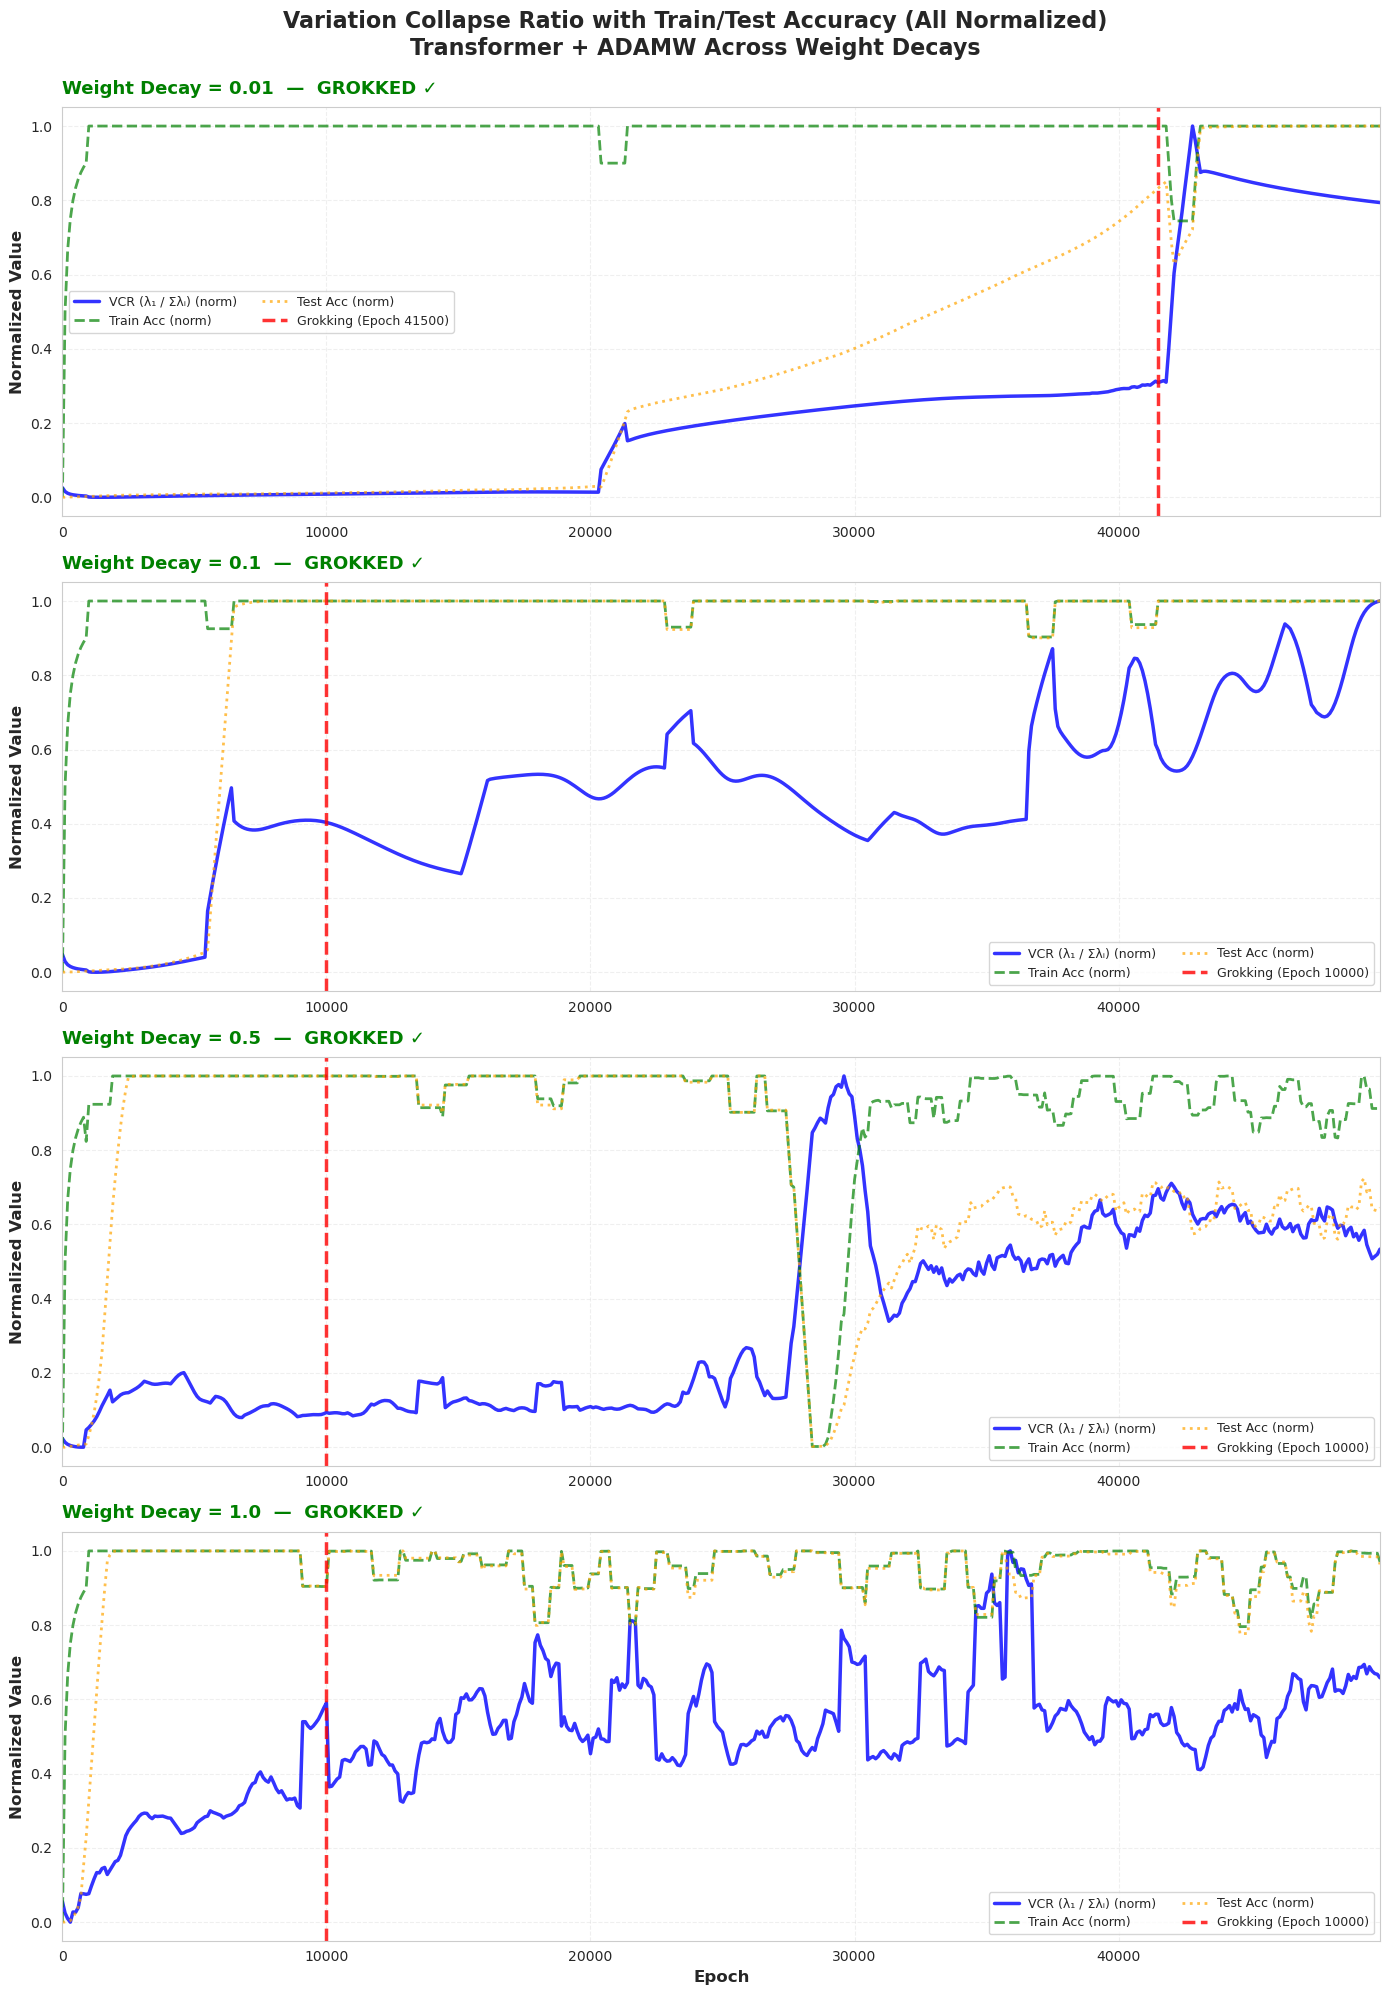

  Generated overlay panel for Variation Collapse Ratio


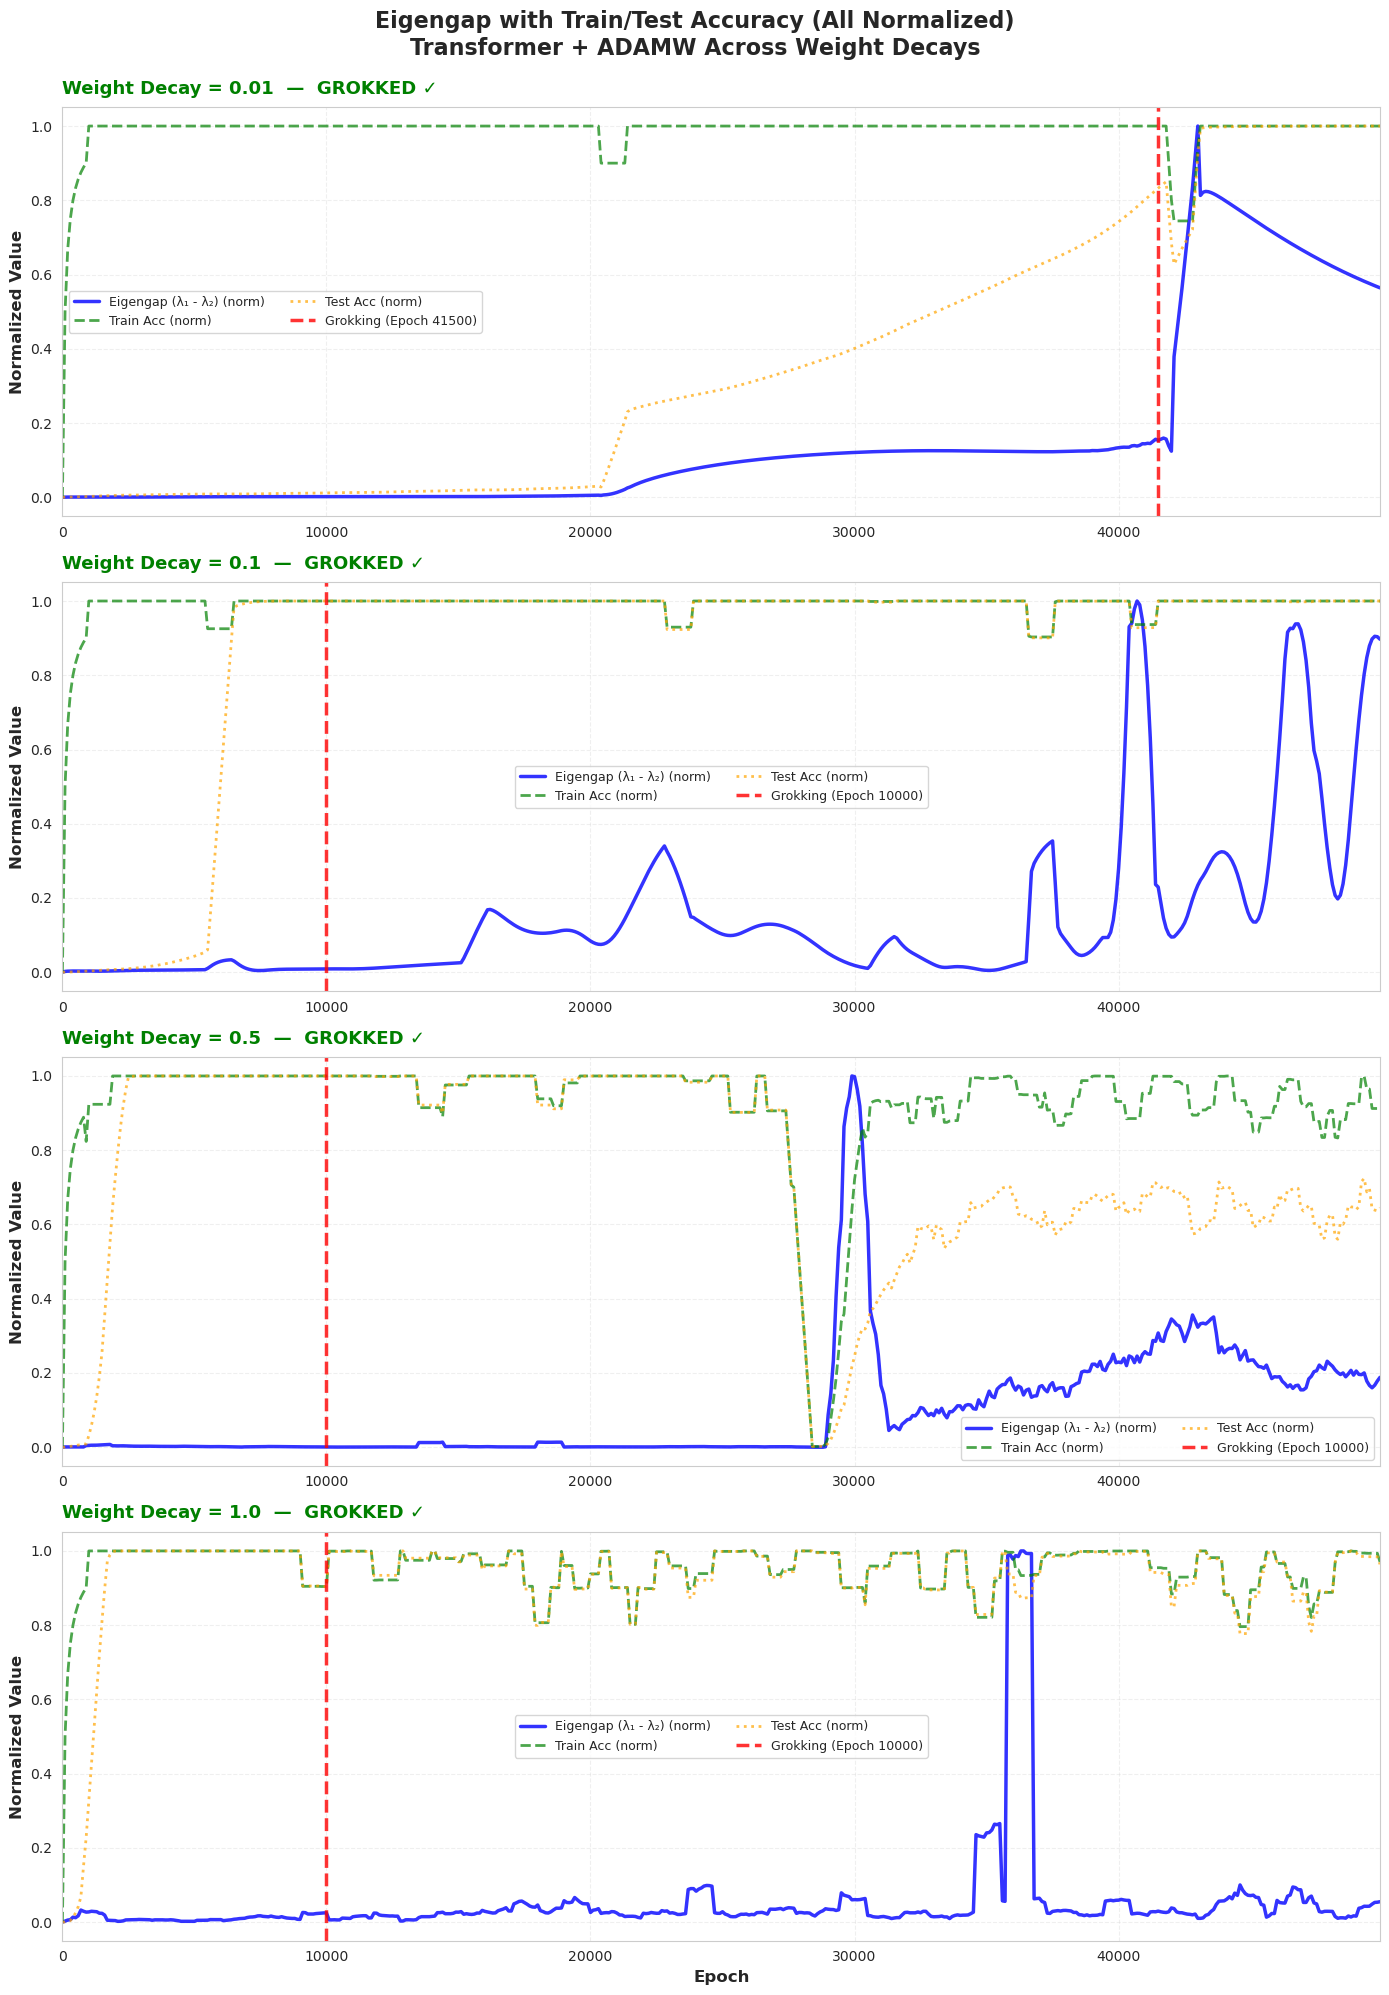

  Generated overlay panel for Eigengap


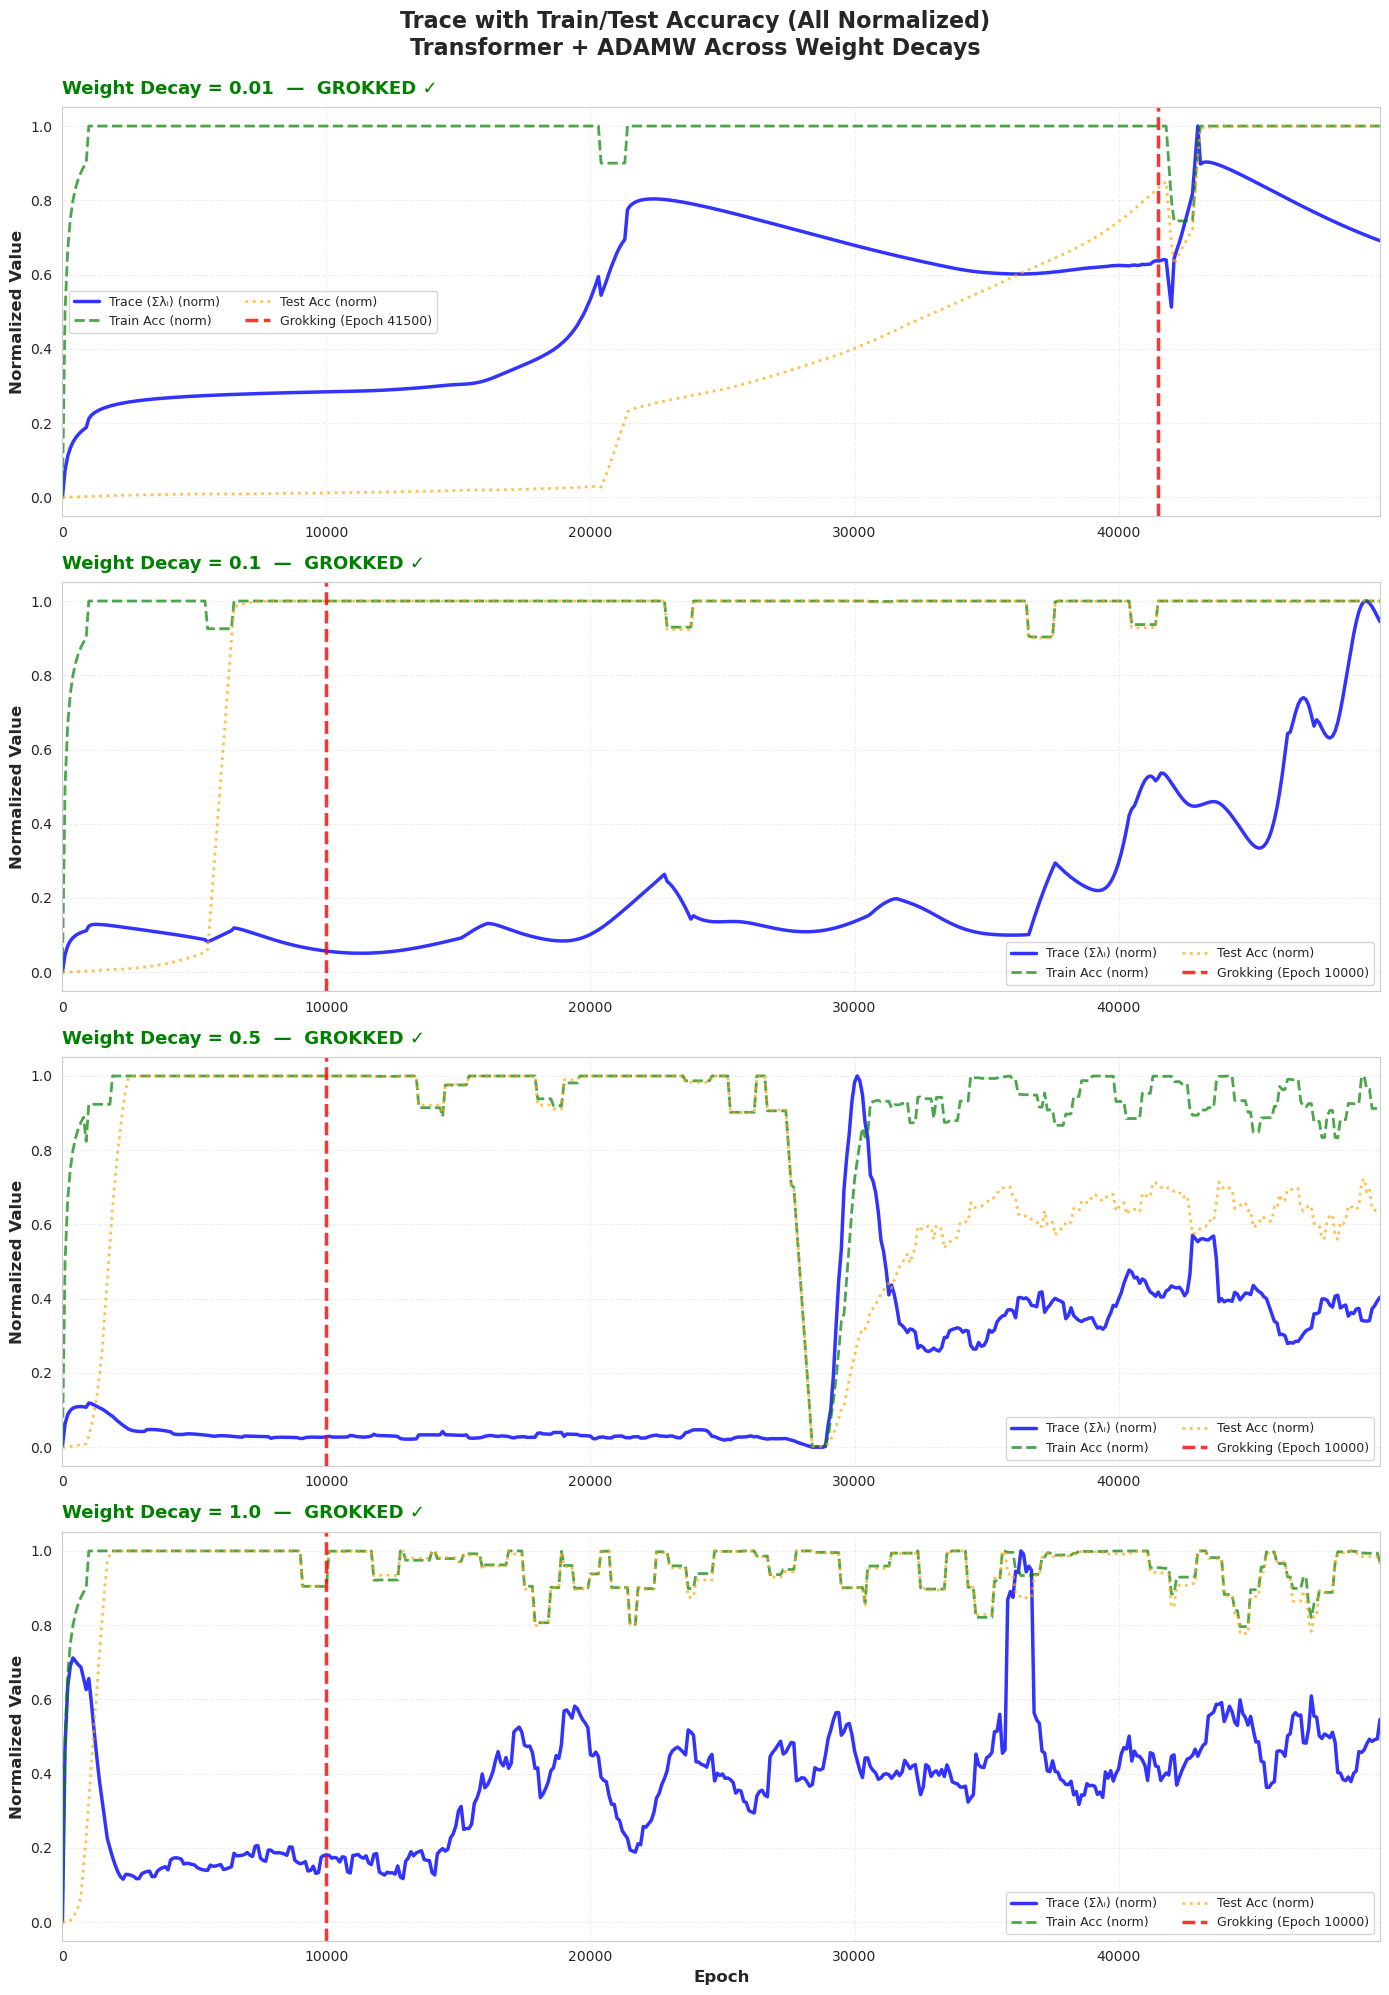

  Generated overlay panel for Trace


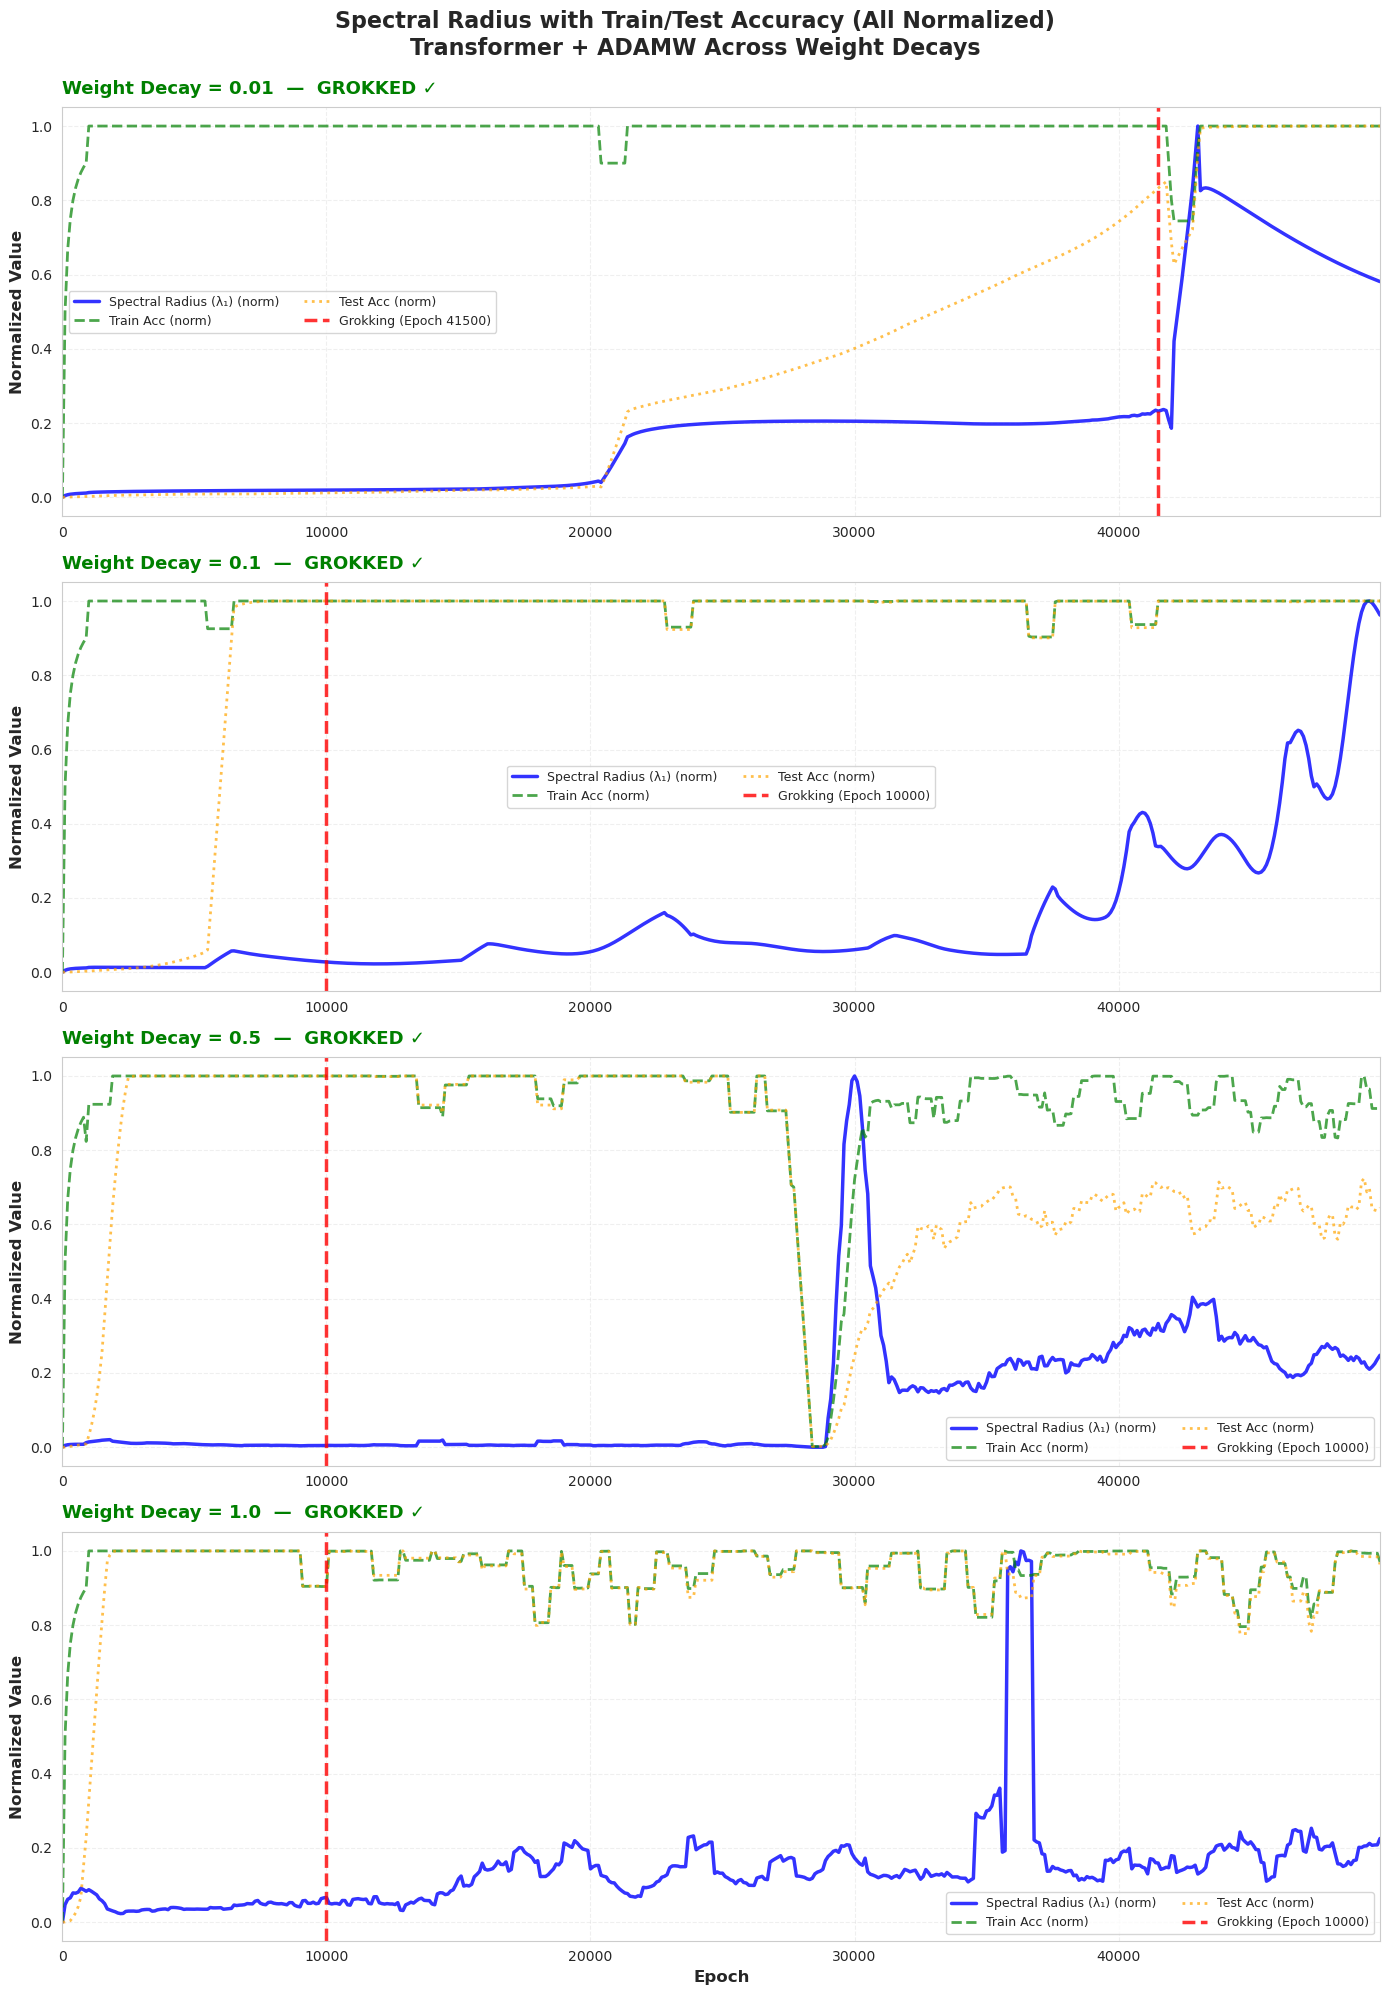

  Generated overlay panel for Spectral Radius

Processing MUON Transformer experiments...


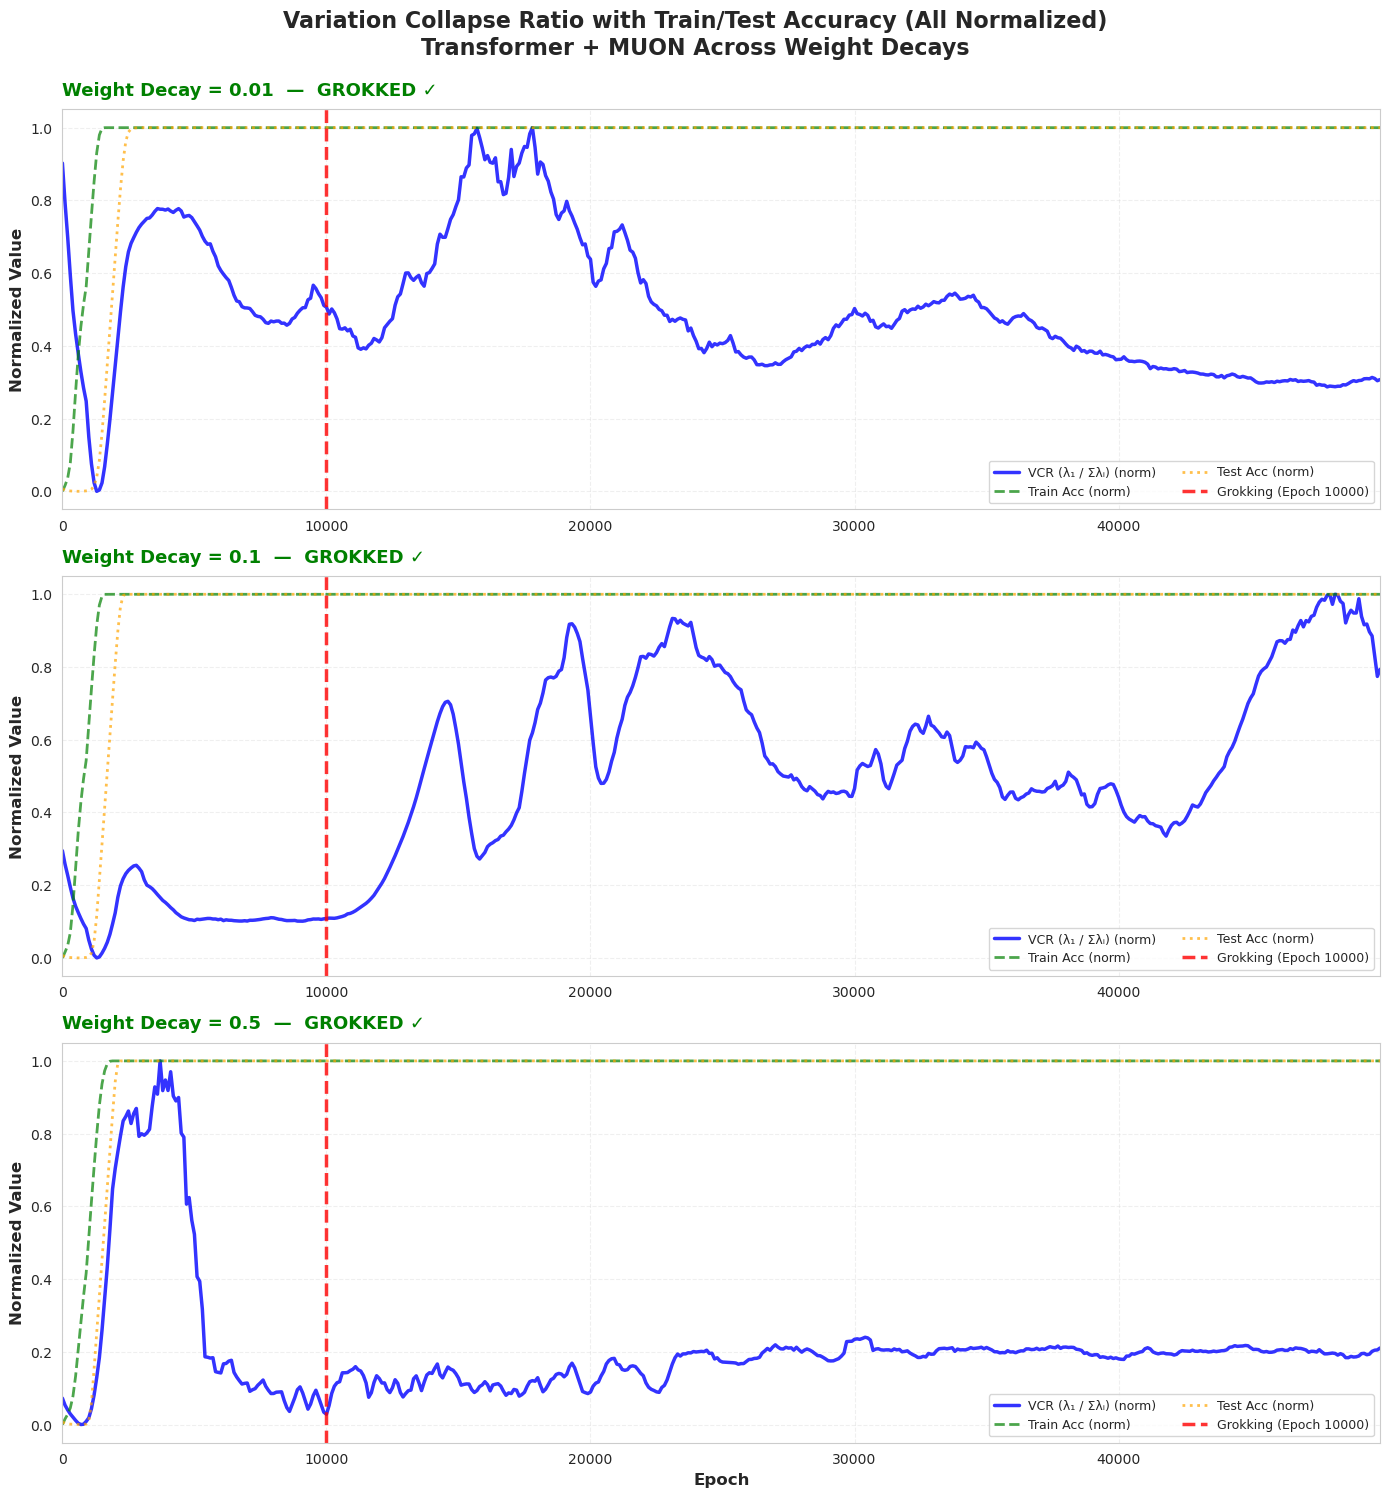

  Generated overlay panel for Variation Collapse Ratio


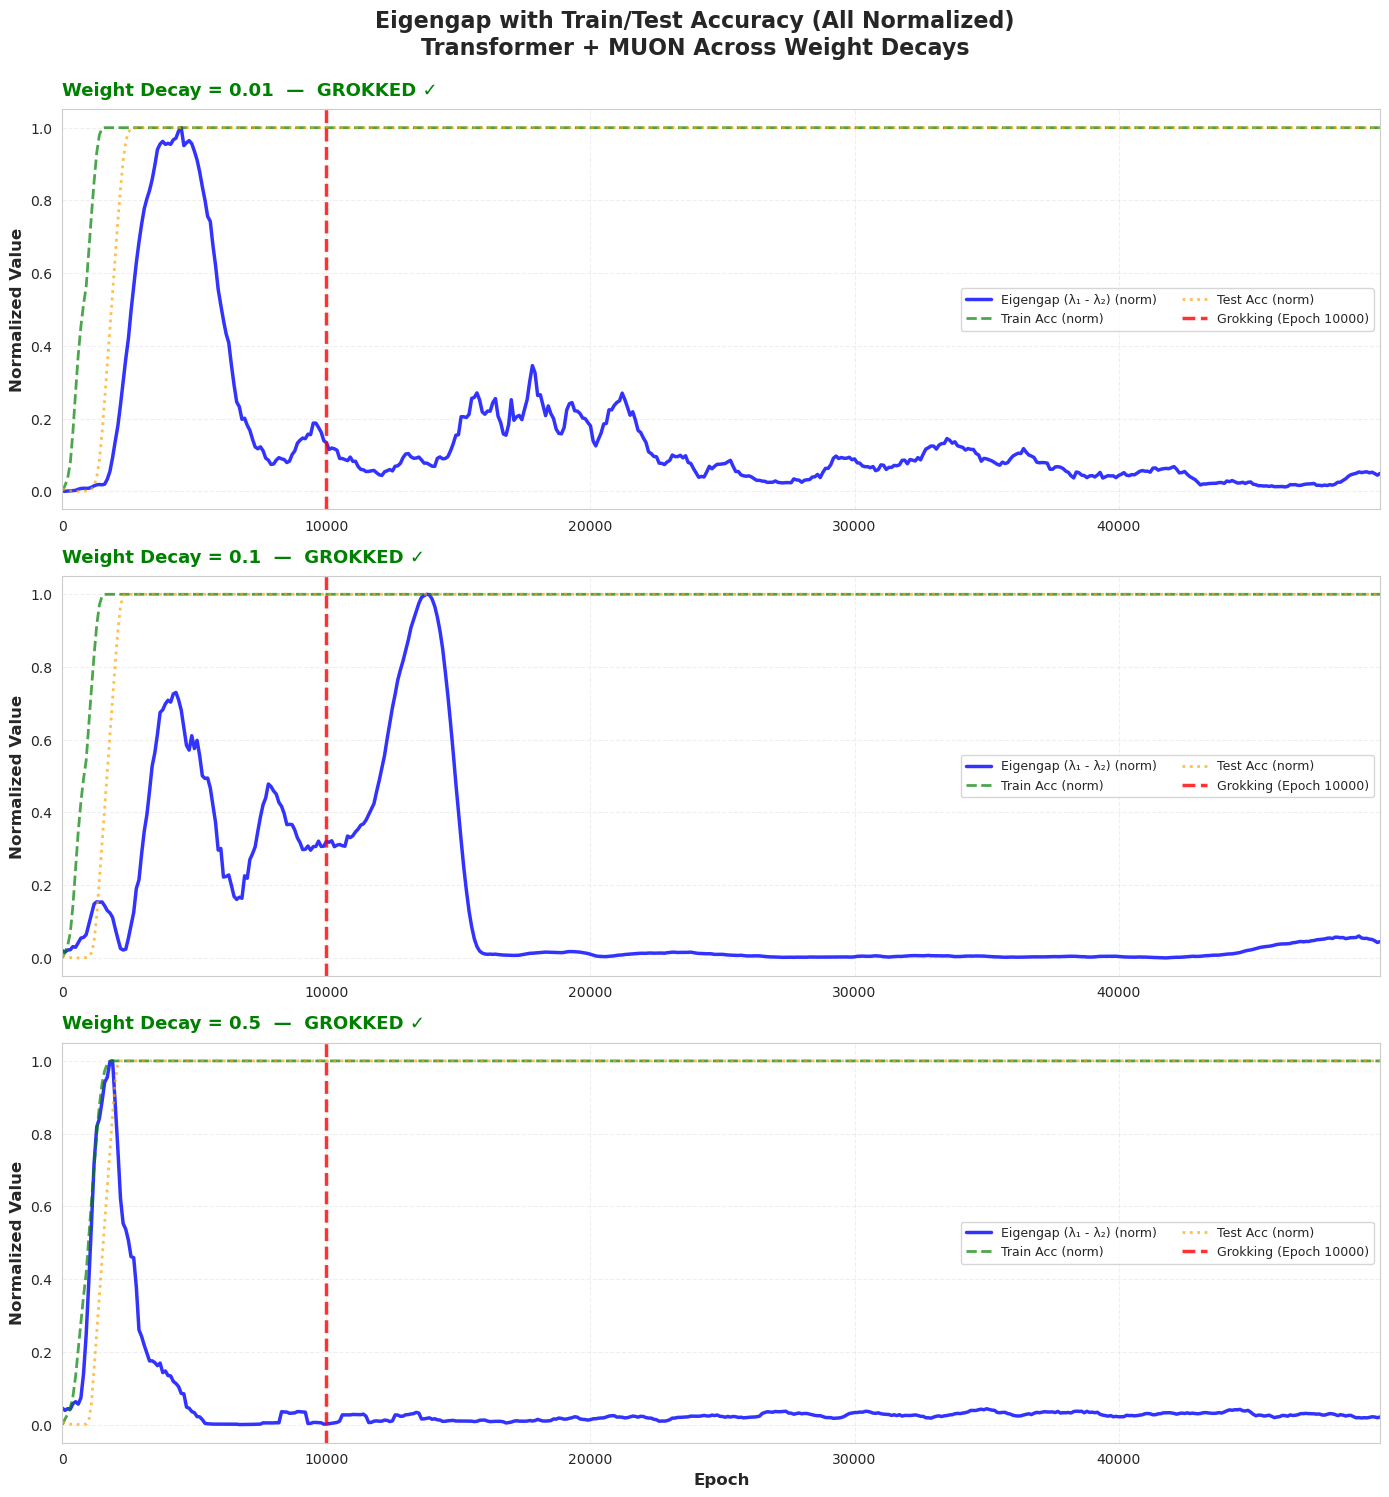

  Generated overlay panel for Eigengap


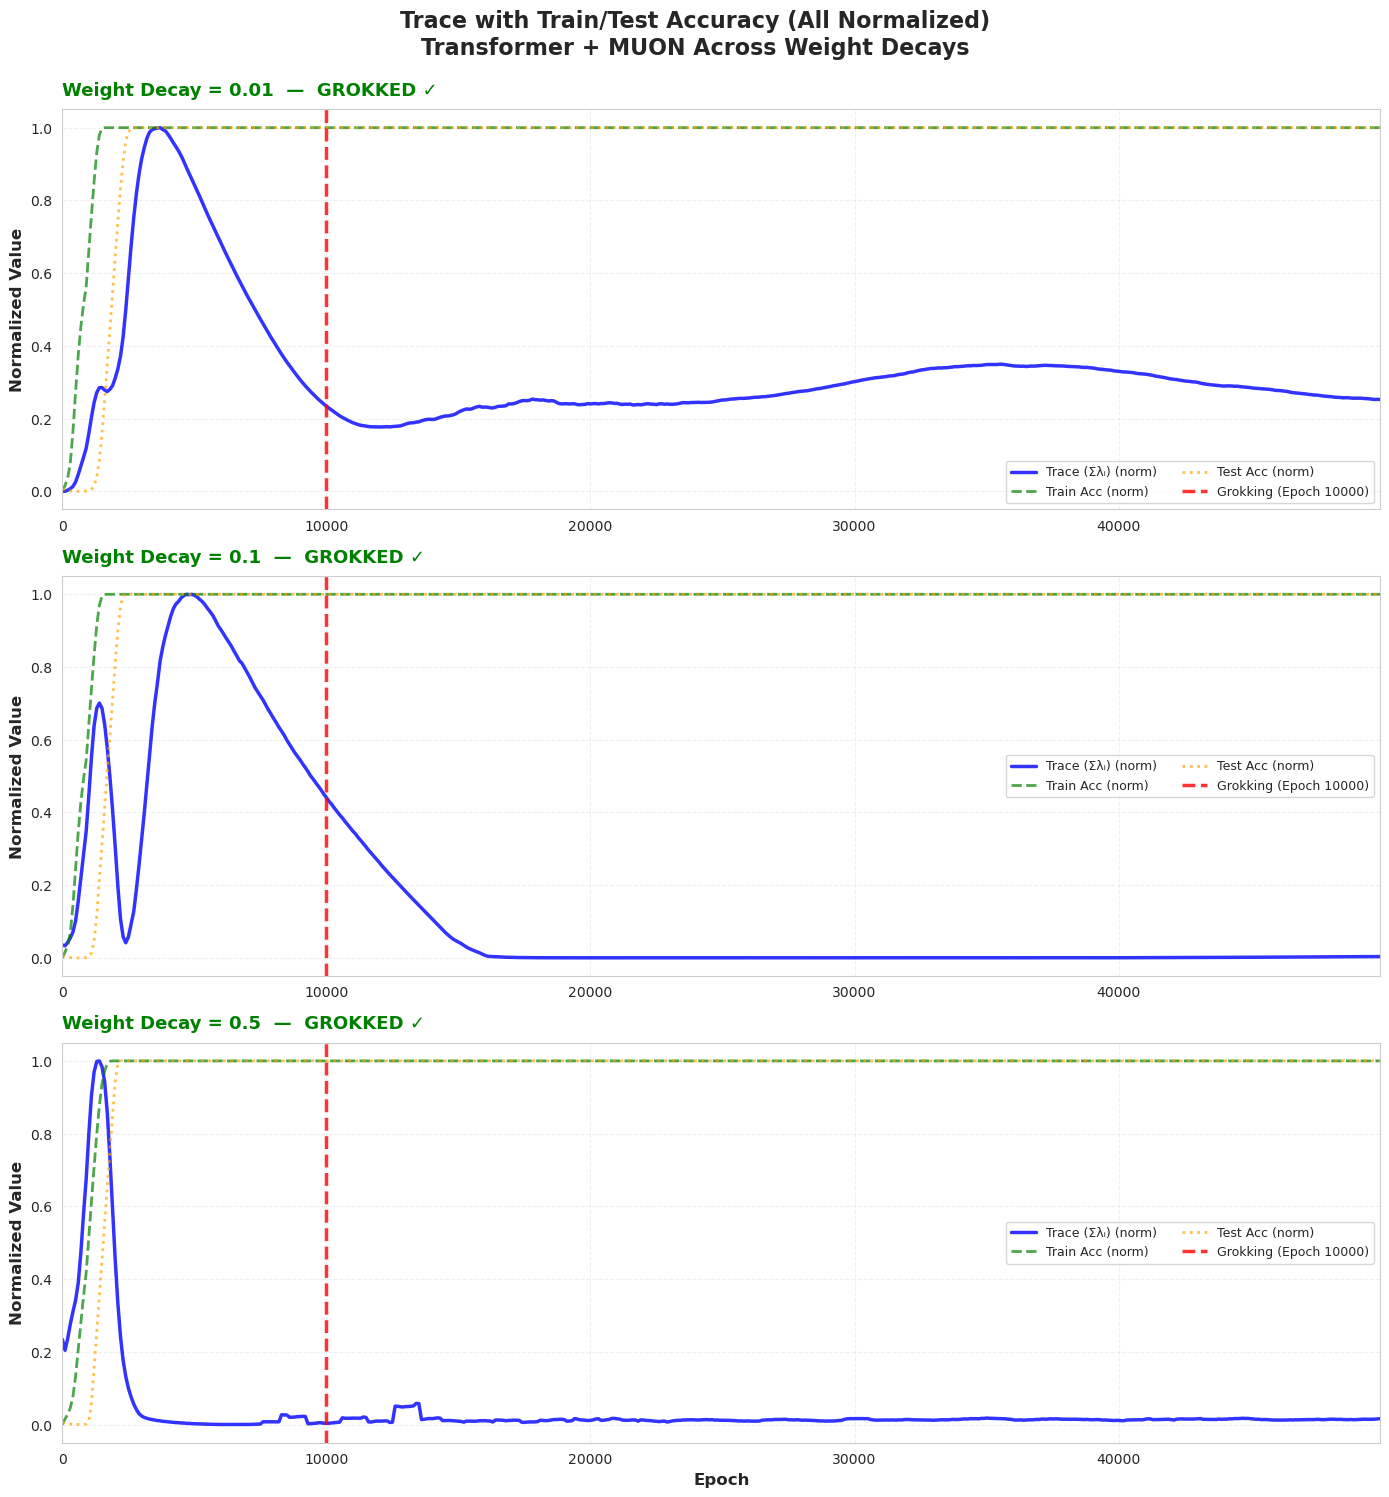

  Generated overlay panel for Trace


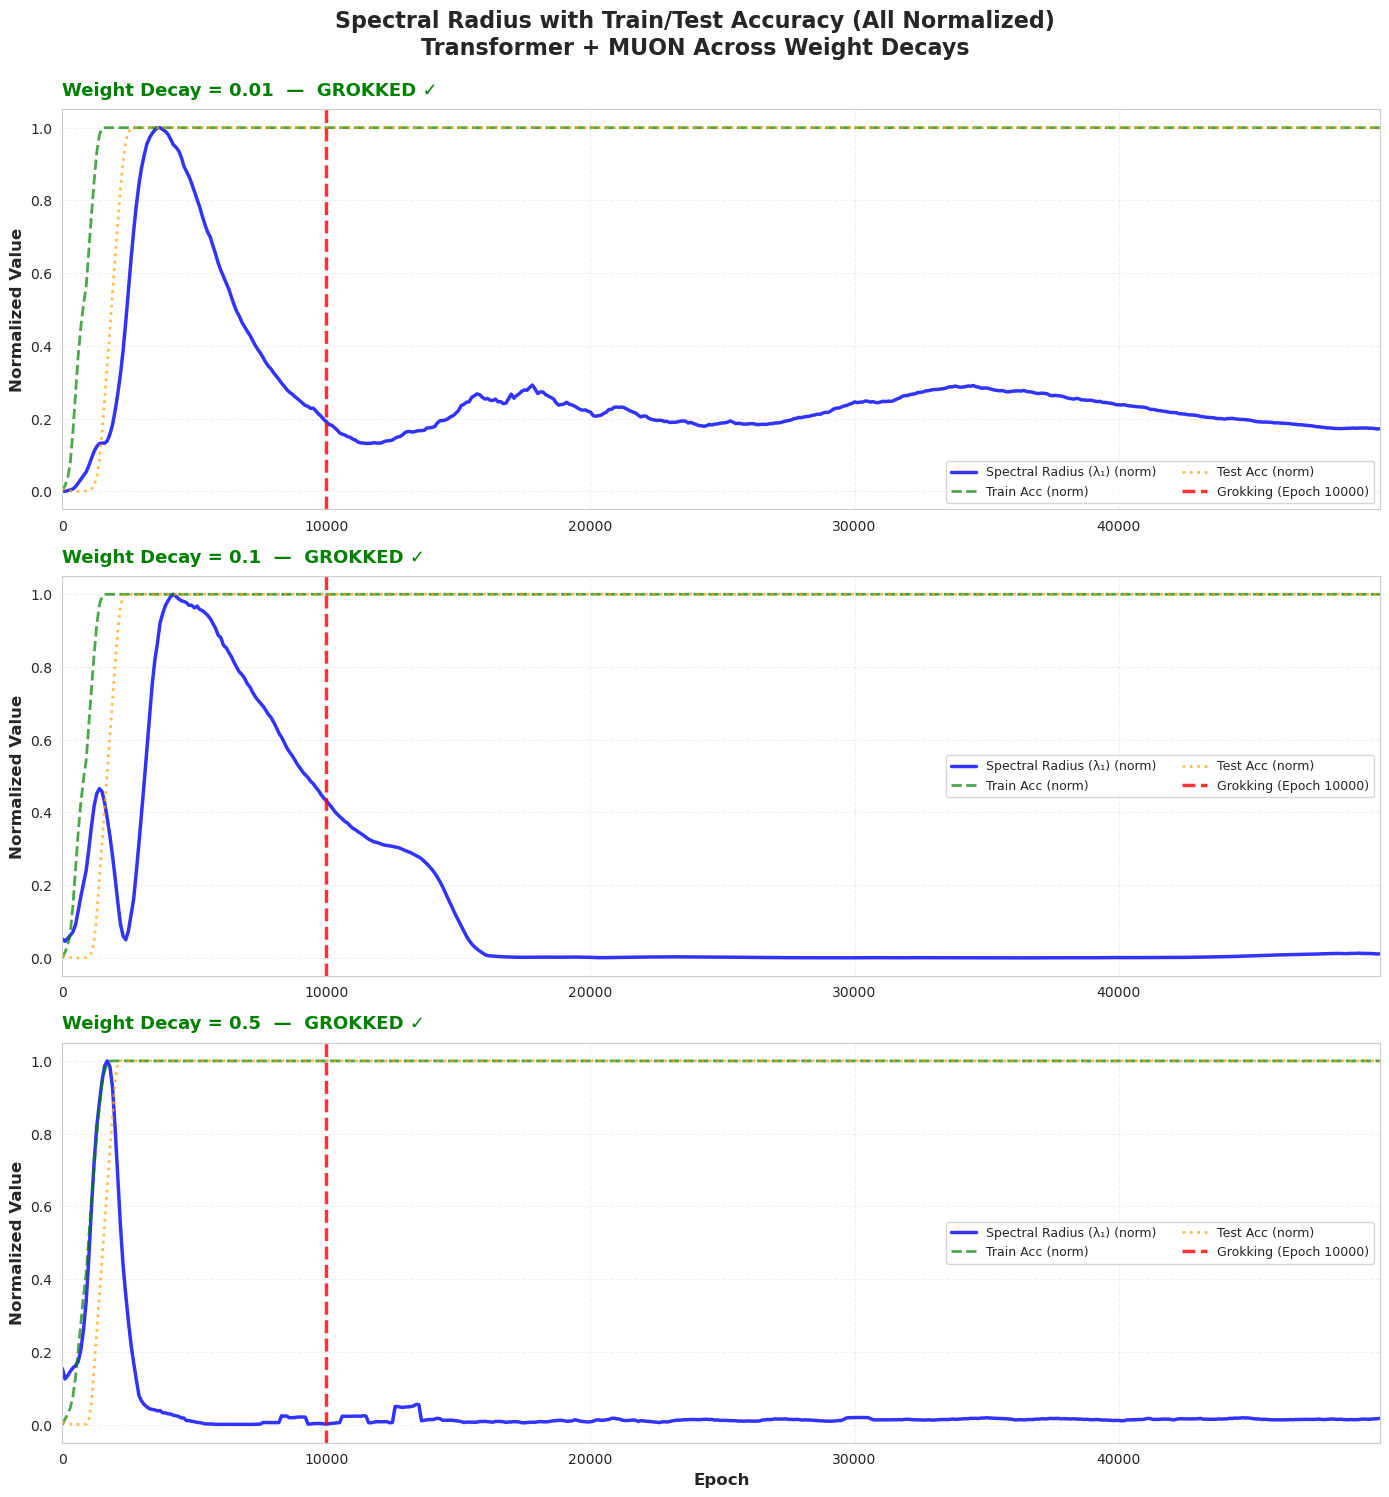

  Generated overlay panel for Spectral Radius

Processing SGD Transformer experiments...
  No data available for Variation Collapse Ratio, skipping...
  No data available for Eigengap, skipping...
  No data available for Trace, skipping...
  No data available for Spectral Radius, skipping...

Generated AGOP metric overlay panels for all optimizers
All values normalized to [0, 1] for direct comparison


In [34]:
# Define AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

def normalize_series(series):
    """Normalize a series to [0, 1] range using min-max normalization."""
    s_min = np.min(series)
    s_max = np.max(series)
    if s_max - s_min < 1e-10:  # Avoid division by zero
        return np.zeros_like(series)
    return (series - s_min) / (s_max - s_min)

print(f"Analyzing AGOP metrics for Transformer experiments by optimizer")
print(f"{'='*80}\n")

# For each optimizer, create overlay plots for each AGOP metric
for opt, sorted_exps in transformer_by_opt.items():
    print(f"\nProcessing {opt.upper()} Transformer experiments...")
    
    for metric_name, metric_label, metric_title in agop_metrics:
        # Collect all data for this optimizer
        all_data = []
        
        for exp_name, exp_data in sorted_exps:
            history = exp_data.get('history', {})
            config = exp_data.get('config', {})
            
            # Check if all required data exists
            if metric_name not in history or 'train_acc' not in history or 'test_acc' not in history:
                continue
            
            epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
            metric_values = np.array(history[metric_name])
            train_acc = np.array(history['train_acc'])
            test_acc = np.array(history['test_acc'])
            
            # Align lengths
            min_len = min(len(epochs), len(metric_values), len(train_acc), len(test_acc))
            epochs = epochs[:min_len]
            metric_values = metric_values[:min_len]
            train_acc = train_acc[:min_len]
            test_acc = test_acc[:min_len]
            
            # Detect grokking
            grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
            grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
            
            # Smooth and normalize
            metric_smooth = smooth_series(metric_values, window=10)
            train_smooth = smooth_series(train_acc, window=10)
            test_smooth = smooth_series(test_acc, window=10)
            
            metric_norm = normalize_series(metric_smooth)
            train_norm = normalize_series(train_smooth)
            test_norm = normalize_series(test_smooth)
            
            all_data.append({
                'exp_name': exp_name,
                'config': config,
                'epochs': epochs,
                'metric_norm': metric_norm,
                'train_norm': train_norm,
                'test_norm': test_norm,
                'grok_epoch': grok_epoch
            })
        
        if not all_data:
            print(f"  No data available for {metric_title}, skipping...")
            continue
        
        max_epochs = max([d['epochs'][-1] for d in all_data if len(d['epochs']) > 0])
        
        # Create vertically stacked subplots (one per weight decay)
        n_subplots = len(all_data)
        fig, axes = plt.subplots(n_subplots, 1, figsize=(14, 5 * n_subplots))
        
        # Handle single subplot case
        if n_subplots == 1:
            axes = [axes]
        
        for idx, data_dict in enumerate(all_data):
            ax = axes[idx]
            
            epochs = data_dict['epochs']
            metric_norm = data_dict['metric_norm']
            train_norm = data_dict['train_norm']
            test_norm = data_dict['test_norm']
            grok_epoch = data_dict['grok_epoch']
            config = data_dict['config']
            wd = config.get('weight_decay', 0)
            
            # Plot all three normalized signals
            ax.plot(epochs, metric_norm, linewidth=2.5, color='blue', alpha=0.8, 
                   label=f'{metric_label} (norm)', linestyle='-')
            ax.plot(epochs, train_norm, linewidth=2.0, color='green', alpha=0.7, 
                   label='Train Acc (norm)', linestyle='--')
            ax.plot(epochs, test_norm, linewidth=2.0, color='orange', alpha=0.7, 
                   label='Test Acc (norm)', linestyle=':')
            
            # Mark grokking epoch if it exists
            if grok_epoch is not None:
                ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2.5, alpha=0.8, 
                          label=f'Grokking (Epoch {grok_epoch})')
                status = "GROKKED ✓"
                title_color = 'green'
            else:
                status = "NO GROK"
                title_color = 'darkred'
            
            # Formatting with unified axes
            ax.set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
            ax.set_title(f'Weight Decay = {wd}  —  {status}', 
                        fontsize=13, fontweight='bold', color=title_color, pad=10, loc='left')
            ax.legend(fontsize=9, loc='best', ncol=2)
            ax.grid(alpha=0.3, linestyle='--')
            
            # Set unified axis limits
            ax.set_xlim([0, max_epochs])
            ax.set_ylim([-0.05, 1.05])
            
            # Only show x-label on bottom plot
            if idx == len(all_data) - 1:
                ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
            else:
                ax.set_xlabel('')
        
        # Overall title
        fig.suptitle(f'{metric_title} with Train/Test Accuracy (All Normalized)\nTransformer + {opt.upper()} Across Weight Decays', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Save figure
        safe_metric_name = metric_name.replace('_', '-')
        plt.savefig(FIGURES_DIR / f'transformer_{opt}_{safe_metric_name}_with_accuracy_overlay.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"  Generated overlay panel for {metric_title}")

print(f"\n{'='*80}")
print(f"Generated AGOP metric overlay panels for all optimizers")
print(f"All values normalized to [0, 1] for direct comparison")
print(f"{'='*80}")


### AGOP Metrics with Overlaid Train/Test Accuracy

Now let's overlay normalized train and test accuracy on the AGOP metrics to see how they co-evolve.
All three signals (AGOP metric, train accuracy, test accuracy) are normalized to [0, 1] range for comparison.


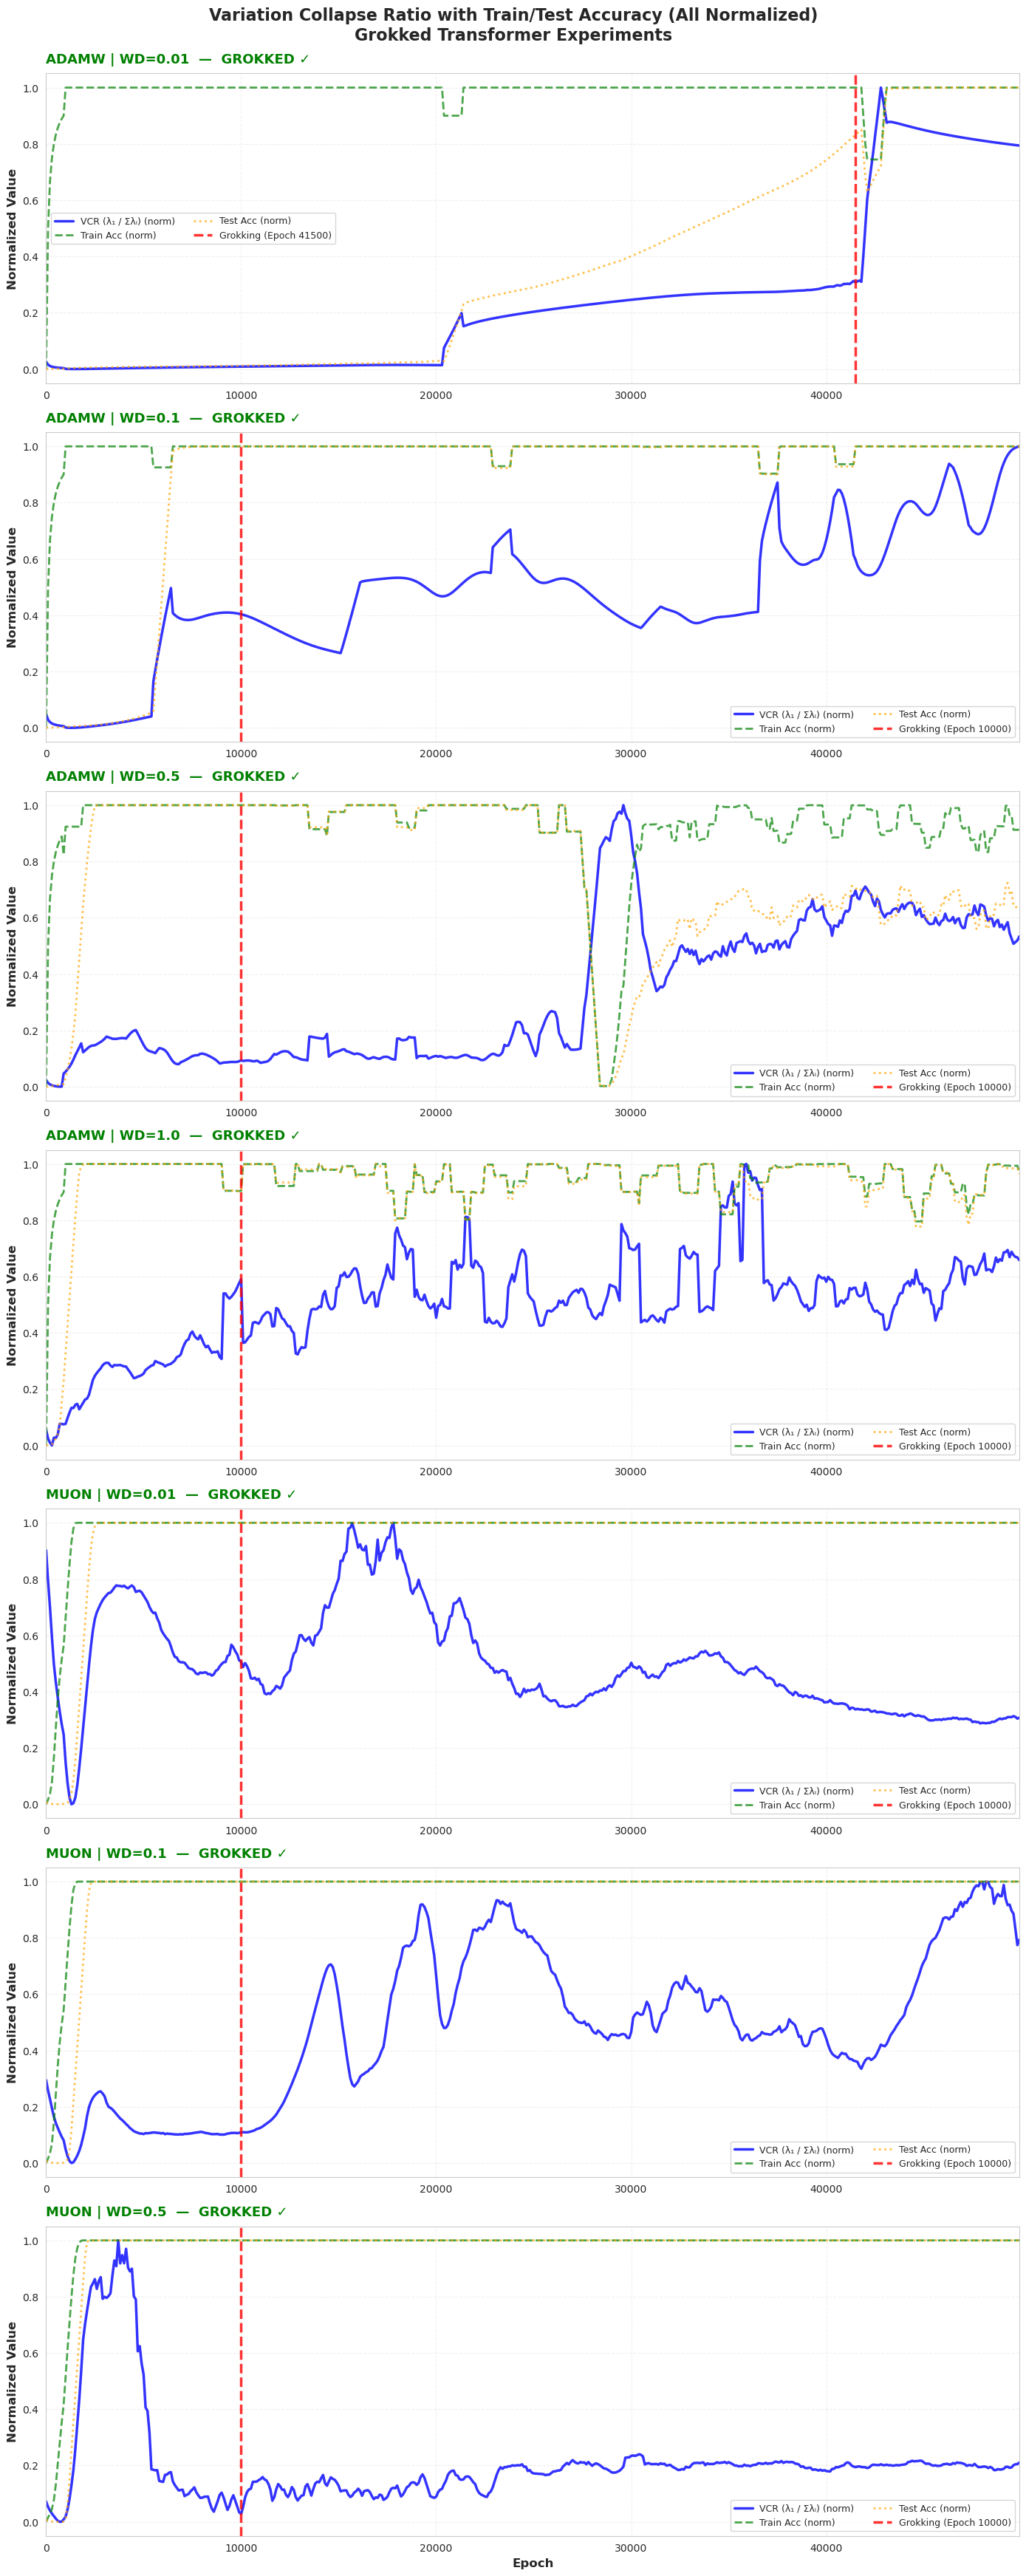

Generated overlay panel for Variation Collapse Ratio


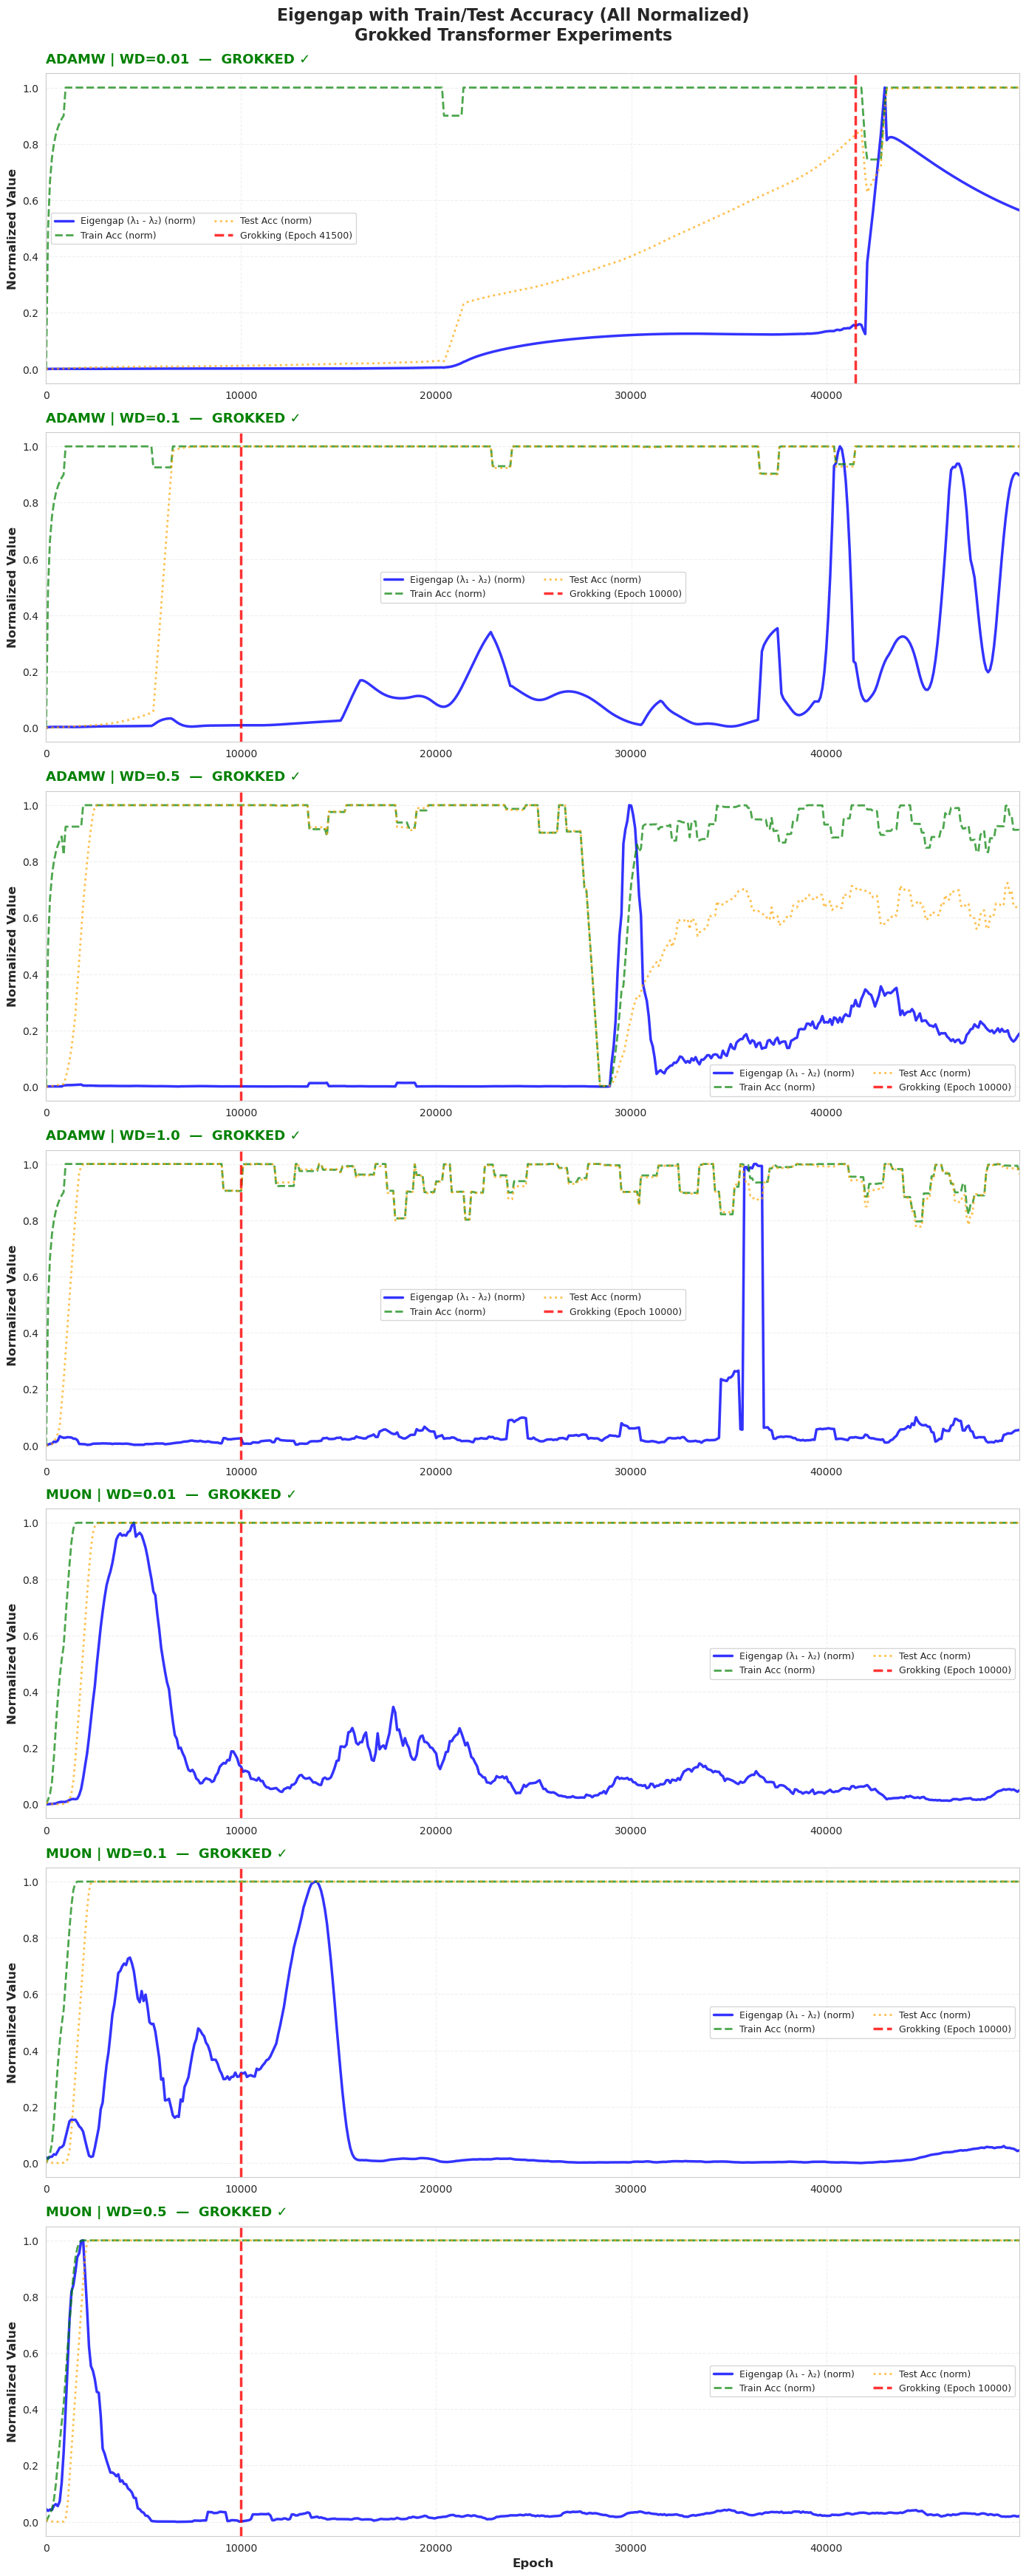

Generated overlay panel for Eigengap


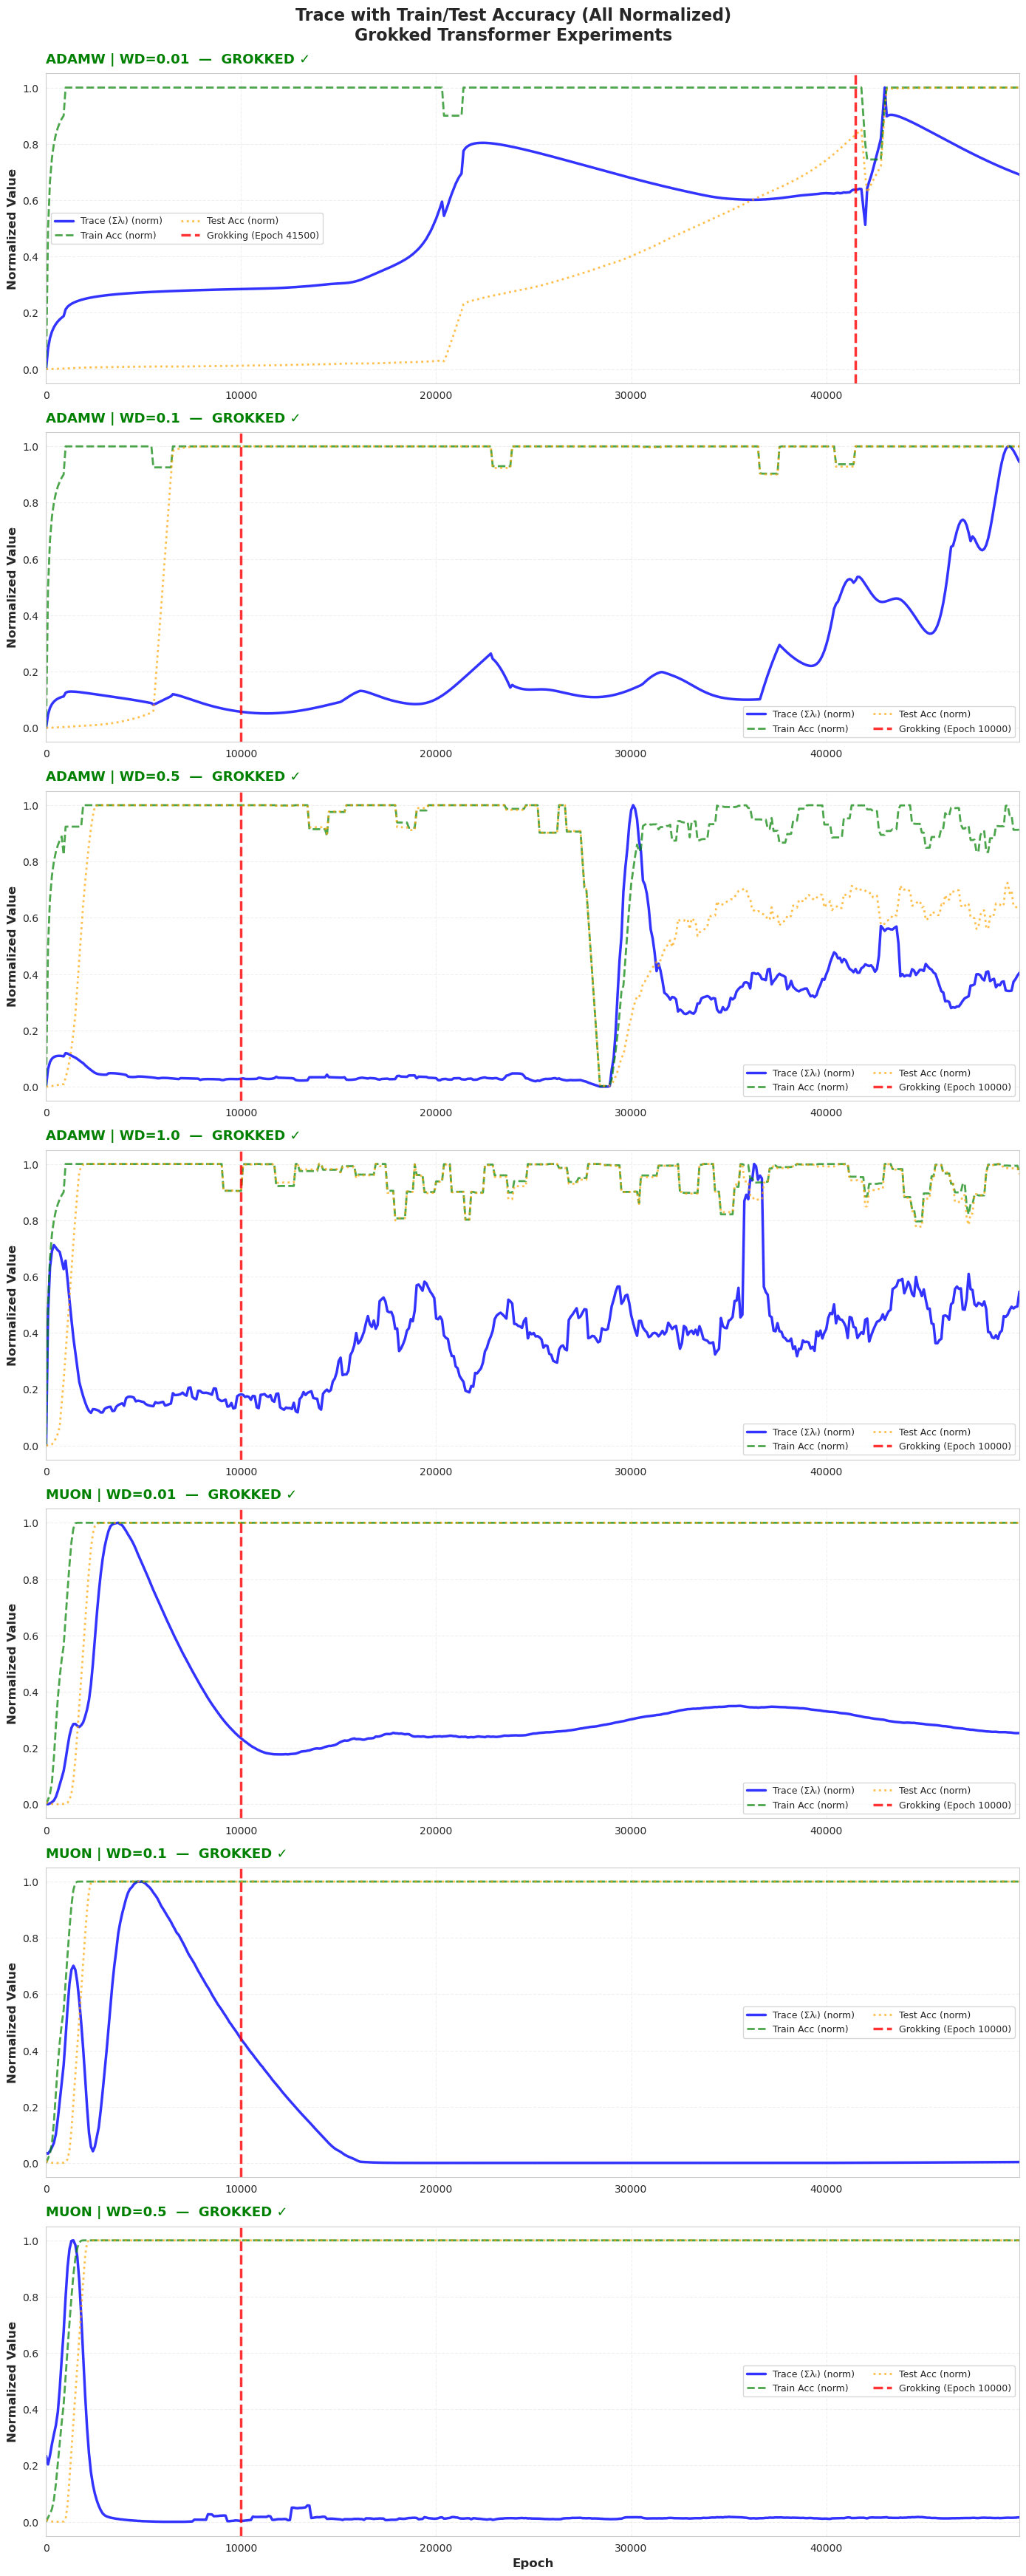

Generated overlay panel for Trace


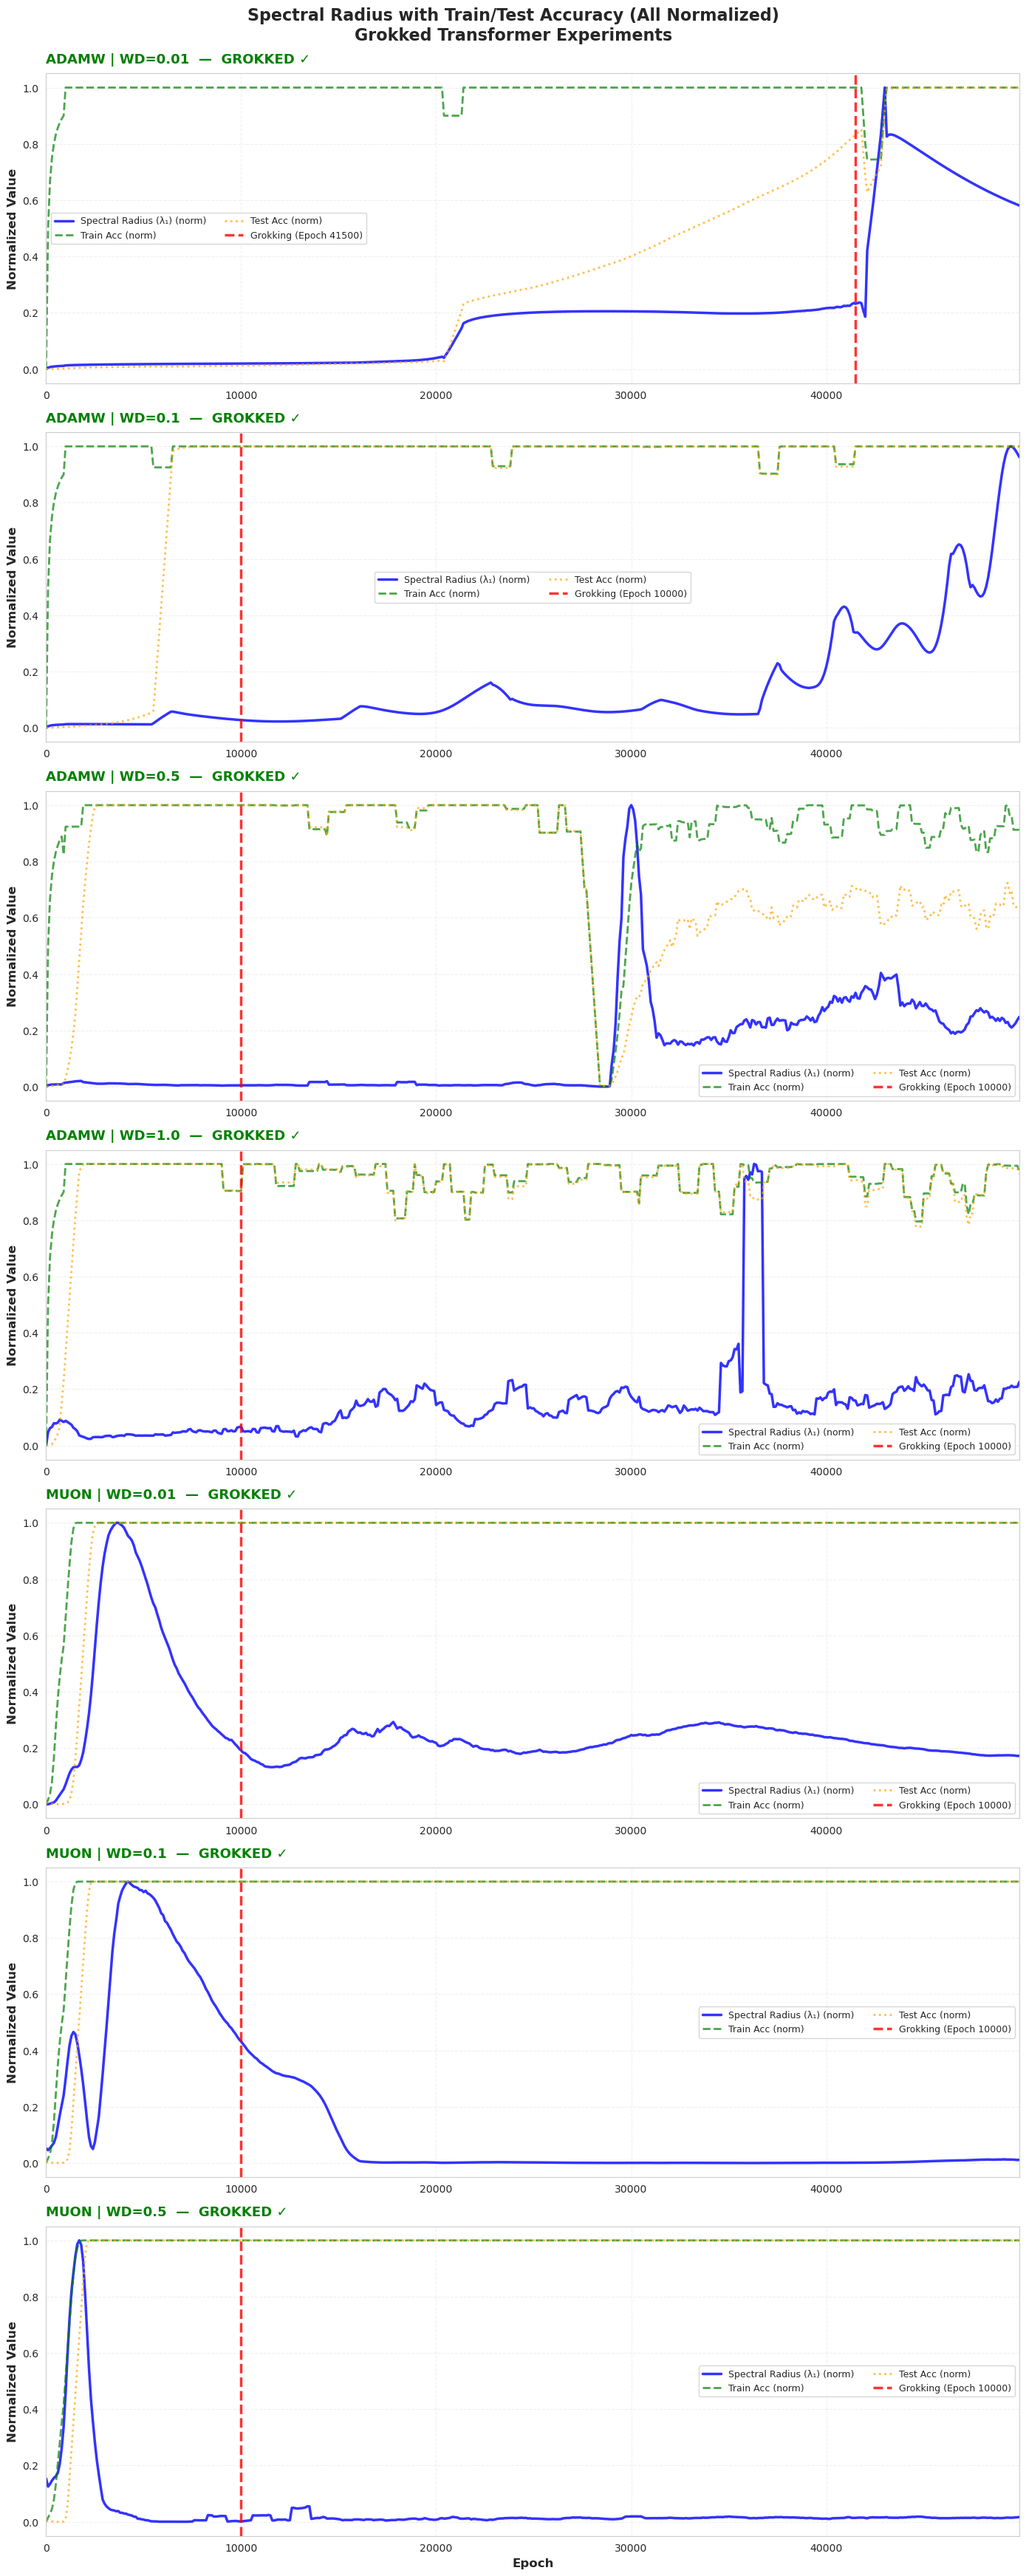

Generated overlay panel for Spectral Radius

Generated AGOP metric overlay panels for grokked experiments
All values normalized to [0, 1] for direct comparison


In [35]:
def normalize_series(series):
    """Normalize a series to [0, 1] range using min-max normalization."""
    s_min = np.min(series)
    s_max = np.max(series)
    if s_max - s_min < 1e-10:  # Avoid division by zero
        return np.zeros_like(series)
    return (series - s_min) / (s_max - s_min)

# Define AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

# Create overlay plots for each AGOP metric for grokked experiments only
for metric_name, metric_label, metric_title in agop_metrics:
    # Collect data for grokked experiments
    grokked_overlay_data = []
    
    for opt, sorted_exps in transformer_by_opt.items():
        for exp_name, exp_data in sorted_exps:
            history = exp_data.get('history', {})
            config = exp_data.get('config', {})
            
            # Check if all required data exists
            if metric_name not in history or 'train_acc' not in history or 'test_acc' not in history:
                continue
            
            epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
            metric_values = np.array(history[metric_name])
            train_acc = np.array(history['train_acc'])
            test_acc = np.array(history['test_acc'])
            
            # Align lengths
            min_len = min(len(epochs), len(metric_values), len(train_acc), len(test_acc))
            epochs = epochs[:min_len]
            metric_values = metric_values[:min_len]
            train_acc = train_acc[:min_len]
            test_acc = test_acc[:min_len]
            
            # Detect grokking
            grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
            grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
            
            # Only include grokked experiments
            if grok_epoch is None:
                continue
            
            # Smooth and normalize
            metric_smooth = smooth_series(metric_values, window=10)
            train_smooth = smooth_series(train_acc, window=10)
            test_smooth = smooth_series(test_acc, window=10)
            
            metric_norm = normalize_series(metric_smooth)
            train_norm = normalize_series(train_smooth)
            test_norm = normalize_series(test_smooth)
            
            grokked_overlay_data.append({
                'exp_name': exp_name,
                'config': config,
                'epochs': epochs,
                'metric_norm': metric_norm,
                'train_norm': train_norm,
                'test_norm': test_norm,
                'grok_epoch': grok_epoch,
                'optimizer': opt
            })
    
    if not grokked_overlay_data:
        print(f"No grokked experiments for {metric_title} overlay, skipping...")
        continue
    
    max_epochs = max([d['epochs'][-1] for d in grokked_overlay_data if len(d['epochs']) > 0])
    
    # Create vertically stacked subplots, one per grokked experiment
    n_plots = len(grokked_overlay_data)
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 5 * n_plots))
    
    if n_plots == 1:
        axes = [axes]
    
    for idx, data_dict in enumerate(grokked_overlay_data):
        ax = axes[idx]
        
        epochs = data_dict['epochs']
        metric_norm = data_dict['metric_norm']
        train_norm = data_dict['train_norm']
        test_norm = data_dict['test_norm']
        grok_epoch = data_dict['grok_epoch']
        config = data_dict['config']
        opt = data_dict['optimizer']
        wd = config.get('weight_decay', 0)
        
        # Plot all three normalized signals
        ax.plot(epochs, metric_norm, linewidth=2.5, color='blue', alpha=0.8, 
               label=f'{metric_label} (norm)', linestyle='-')
        ax.plot(epochs, train_norm, linewidth=2.0, color='green', alpha=0.7, 
               label='Train Acc (norm)', linestyle='--')
        ax.plot(epochs, test_norm, linewidth=2.0, color='orange', alpha=0.7, 
               label='Test Acc (norm)', linestyle=':')
        
        # Mark grokking epoch
        if grok_epoch is not None:
            ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2.5, alpha=0.8, 
                      label=f'Grokking (Epoch {grok_epoch})')
        
        # Formatting with unified axes
        ax.set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
        ax.set_title(f'{opt.upper()} | WD={wd}  —  GROKKED ✓', 
                    fontsize=13, fontweight='bold', color='green', pad=10, loc='left')
        ax.legend(fontsize=9, loc='best', ncol=2)
        ax.grid(alpha=0.3, linestyle='--')
        
        # Set unified axis limits
        ax.set_xlim([0, max_epochs])
        ax.set_ylim([-0.05, 1.05])
        
        # Only show x-label on bottom plot
        if idx == len(grokked_overlay_data) - 1:
            ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        else:
            ax.set_xlabel('')
    
    # Overall title
    fig.suptitle(f'{metric_title} with Train/Test Accuracy (All Normalized)\nGrokked Transformer Experiments', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    safe_metric_name = metric_name.replace('_', '-')
    plt.savefig(FIGURES_DIR / f'transformer_{safe_metric_name}_with_accuracy_overlay.png', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Generated overlay panel for {metric_title}")

print(f"\n{'='*80}")
print(f"Generated AGOP metric overlay panels for grokked experiments")
print(f"All values normalized to [0, 1] for direct comparison")
print(f"{'='*80}")


### Interpreting AGOP Metrics

**What to look for in the plots above:**

1. **Variation Collapse Ratio (VCR)**: Measures how much variance is captured by the top eigenvalue. Higher VCR indicates more collapsed representation (lower dimensional). During grokking, VCR may show sudden changes as the network reorganizes its representations.

2. **Eigengap**: Difference between top two eigenvalues. Large eigengap indicates strong dominance of first principal component. May indicate transition from distributed to more structured representations.

3. **Trace**: Sum of all eigenvalues (total variance in activations). Reflects overall energy or magnitude of representations. Weight decay should generally decrease trace over time.

4. **Spectral Radius**: Largest eigenvalue. Governs gradient flow and stability. Sudden changes may correlate with phase transitions in learning.

**Expected patterns for grokking vs non-grokking:**
- Grokking experiments may show discontinuities or inflection points in AGOP metrics around the grokking epoch
- Non-grokking experiments likely show smoother, monotonic evolution
- Weight decay should affect the magnitude and dynamics of these metrics


---
# Section A: Optimizer Comparison

Compare performance of AdamW, Muon, and SGD optimizers within each architecture.


## A1: MLP Architecture - Optimizer Comparison


In [ ]:
# Filter MLP experiments
mlp_exps = filter_experiments(experiments, architecture='mlp')
mlp_df = summary_df[summary_df['architecture'] == 'mlp'].copy()

print(f"MLP Experiments: {len(mlp_exps)}")
print(f"\nPerformance by Optimizer and Weight Decay:")
print(f"="*80)

# Create pivot table
mlp_pivot = mlp_df.pivot_table(
    values=['final_test_acc', 'grokked', 'grok_epoch'],
    index='optimizer',
    columns='weight_decay',
    aggfunc={'final_test_acc': 'mean', 'grokked': 'sum', 'grok_epoch': lambda x: x.max() if any(x > 0) else -1}
)

display(mlp_pivot)


In [ ]:
# Plot test accuracy curves for MLP by optimizer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
optimizers = ['adamw', 'muon', 'sgd']

for idx, opt in enumerate(optimizers):
    ax = axes[idx]
    opt_exps = filter_experiments(mlp_exps, optimizer=opt)
    
    for exp_name, exp_data in opt_exps.items():
        history = exp_data['history']
        config = exp_data['config']
        
        if 'test_acc' not in history:
            continue
            
        epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
        test_acc = np.array(history['test_acc'])
        wd = config.get('weight_decay', 0)
        
        grokked = classify_grokking(exp_data)
        linestyle = '-' if grokked else '--'
        label = f"WD={wd}" + (" ✓" if grokked else "")
        
        ax.plot(epochs, test_acc, linestyle=linestyle, linewidth=2, label=label, alpha=0.8)
    
    ax.axhline(y=0.95, color='r', linestyle=':', alpha=0.5, label='Grokking threshold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Test Accuracy', fontsize=11)
    ax.set_title(f'MLP + {opt.upper()}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mlp_optimizer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: mlp_optimizer_comparison.png")


## A2: Transformer Architecture - Optimizer Comparison


In [ ]:
# Filter Transformer experiments
trans_exps = filter_experiments(experiments, architecture='transformer')
trans_df = summary_df[summary_df['architecture'] == 'transformer'].copy()

print(f"Transformer Experiments: {len(trans_exps)}")
print(f"\nPerformance by Optimizer and Weight Decay:")
print(f"="*80)

# Create pivot table
trans_pivot = trans_df.pivot_table(
    values=['final_test_acc', 'grokked', 'grok_epoch'],
    index='optimizer',
    columns='weight_decay',
    aggfunc={'final_test_acc': 'mean', 'grokked': 'sum', 'grok_epoch': lambda x: x.max() if any(x > 0) else -1}
)

display(trans_pivot)


---
# Section B: Weight Decay Comparison

Analyze the effect of weight decay on grokking within each optimizer.


---
# Section C: AGOP Metrics Analysis

Analyze AGOP metric evolution and relationship to grokking.


In [ ]:
# Separate grokking and non-grokking experiments
grok_exps = {name: data for name, data in experiments.items() if classify_grokking(data)}
nogrok_exps = {name: data for name, data in experiments.items() if not classify_grokking(data)}

print(f"Grokking experiments: {len(grok_exps)}")
print(f"Non-grokking experiments: {len(nogrok_exps)}")
print(f"\nGrokking experiments:")
for name in grok_exps.keys():
    grok_epoch = compute_time_to_grok(grok_exps[name])
    print(f"  - {name}: grokked at epoch {grok_epoch}")


In [ ]:
# Plot AGOP metrics: grokking vs non-grokking
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)'),
    ('agop_trace', 'Trace (Σλᵢ)'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (metric_name, metric_label) in enumerate(agop_metrics):
    ax = axes[idx]
    
    # Collect grokking data
    grok_data = []
    for exp_data in grok_exps.values():
        history = exp_data.get('history', {})
        if metric_name in history:
            grok_data.append(np.array(history[metric_name]))
    
    # Collect non-grokking data
    nogrok_data = []
    for exp_data in nogrok_exps.values():
        history = exp_data.get('history', {})
        if metric_name in history:
            nogrok_data.append(np.array(history[metric_name]))
    
    if grok_data:
        # Align lengths
        min_len = min(len(d) for d in grok_data)
        grok_aligned = np.array([d[:min_len] for d in grok_data])
        grok_mean = np.mean(grok_aligned, axis=0)
        grok_std = np.std(grok_aligned, axis=0)
        
        # Get epochs
        first_exp = list(grok_exps.values())[0]
        epochs = np.array(first_exp['history'].get('epoch', range(min_len)))[:min_len]
        
        # Smooth
        grok_mean_smooth = smooth_series(grok_mean, window=5)
        
        ax.plot(epochs, grok_mean_smooth, 'g-', linewidth=2.5, label=f'Grokking (n={len(grok_data)})')
        ax.fill_between(epochs, grok_mean_smooth - grok_std[:min_len], 
                        grok_mean_smooth + grok_std[:min_len], alpha=0.3, color='g')
    
    if nogrok_data:
        # Align lengths
        min_len = min(len(d) for d in nogrok_data)
        nogrok_aligned = np.array([d[:min_len] for d in nogrok_data])
        nogrok_mean = np.mean(nogrok_aligned, axis=0)
        nogrok_std = np.std(nogrok_aligned, axis=0)
        
        epochs = np.array(first_exp['history'].get('epoch', range(min_len)))[:min_len]
        
        # Smooth
        nogrok_mean_smooth = smooth_series(nogrok_mean, window=5)
        
        ax.plot(epochs, nogrok_mean_smooth, 'r-', linewidth=2.5, label=f'No Grokking (n={len(nogrok_data)})')
        ax.fill_between(epochs, nogrok_mean_smooth - nogrok_std[:min_len],
                        nogrok_mean_smooth + nogrok_std[:min_len], alpha=0.3, color='r')
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label}: Grokking vs Non-Grokking', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'agop_grokking_vs_nogrokking.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: agop_grokking_vs_nogrokking.png")


---
# Summary and Key Findings

## Best Configurations
Based on the analysis above, identify the top performing configurations.


In [ ]:
# Display top 5 experiments by final test accuracy
print(f"\nTop 5 Configurations by Final Test Accuracy:")
print(f"="*80)

top_df = summary_df.nlargest(5, 'final_test_acc')[[
    'experiment', 'architecture', 'optimizer', 'weight_decay', 
    'final_test_acc', 'grokked', 'grok_epoch'
]]

display(top_df)

# Summary statistics
print(f"\nKey Findings:")
print(f"-"*80)
print(f"1. Overall grokking rate: {grok_rate:.1f}%")
print(f"2. Best architecture: {summary_df.groupby('architecture')['final_test_acc'].mean().idxmax()}")
print(f"3. Best optimizer: {summary_df.groupby('optimizer')['final_test_acc'].mean().idxmax()}")

print(f"\nAnalysis complete! All figures saved to: {FIGURES_DIR.absolute()}")


## C1: Grokking vs Non-Grokking - AGOP Comparison


In [ ]:
# AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

# Get transformer experiments grouped by optimizer
transformer_by_opt = {}
for opt in ['adamw', 'muon', 'sgd']:
    opt_exps = {name: data for name, data in transformer_exps.items() 
                if data['config'].get('optimizer') == opt}
    if len(opt_exps) > 0:
        transformer_by_opt[opt] = sorted(opt_exps.items(), 
                                         key=lambda x: x[1]['config'].get('weight_decay', 0))

print(f"Analyzing AGOP metrics for Transformer experiments by optimizer")
print(f"Optimizers: {list(transformer_by_opt.keys())}")
